In [1]:
print("Hello World!")

Hello World!


In [2]:
# TODO: spojiti data.txt i labels.txt u jedan data.csv (prepakovani podaci) i proveriti strukturu
# ocekujem da bude 4480 redova, 40 razlicitih subjekata, pa za svakog po 112 redova merenja, i za svakog subjekta po 28 merenja iz svake aktivnost
# odnosno, klase su balansirane
# ocekujem 535 kolona, od kojih su 533 atributi koji ucestvuju u klasifikaciji, prvi atribut je id subjekta koji ucestvuje u podeli i uzorkovanju podataka,
# poslednji atribut je ciljna klasa (1-neutral, 2-emontional, 3-mental, 4-physical)
# nema nedostajucih vrednosti, svi atributi su realne vrednosti, i ciljna klasa koja je kategorickog tipa je vec kodirana
# atributi za EDA signale iz ruke i sake imaju ista imena (jesu isti, ali za razlicite delove tela), pa treba dodati prefikse kako bi se znalo o kojem tacno signalu je rec
# prvo idu 104 EDA signala vezanih za ruku, pa potom 104 EDA signala vezana za saku

csv_filename = "data/data.csv"

# granice blokova atributa (indeksi kolona, 0-bazirani):
# 0 - subject_id, 1..174 - ECG, 175..325 - TEB, 326..429 - EDA ruka, 430..533 - EDA saka, 534 - target
EDA_ARM_START = 326
EDA_HAND_START = 430

def transform_to_csv(labels: str = "", data: str = ""):
    with open(labels, "r") as f_labels:
        with open(data, "r") as f_data:
            labels = f_labels.readlines()
            labels = list(map(str.strip, labels))
            data = f_data.readlines()
            data = list(map(str.strip, data))
            labels = labels[:-1]
            # zamenjujemo naziv poslednjeg ciljnog atributa u 'target'
            labels.append("target")
            # zamenjujemo naziv prvog atributa u subject_id
            labels[0] = "subject_id"

            # EDA podaci za ruku i saku imaju ista imena, pa ih transformisemo dodavanjem dela tela na kojem su mereni
            # opsezi se ne smeju preklapati, inace bi kolona na granici dobila oba prefiksa (npr. EDA_Hand_Arm_...)
            for i in range(EDA_ARM_START, EDA_HAND_START):
                prefix, sufix = labels[i].split("_", maxsplit=1)
                labels[i] = prefix + "_Arm_" + sufix
            for i in range(EDA_HAND_START, len(labels) - 1):
                prefix, sufix = labels[i].split("_", maxsplit=1)
                labels[i] = prefix + "_Hand_" + sufix

            print(labels[:EDA_ARM_START])
            print(labels[EDA_ARM_START:EDA_HAND_START])
            print(labels[EDA_HAND_START:-1])
            csv_data = data
            csv_data.insert(0, ",".join(labels))
            with open(csv_filename, "w") as f_csv:
                f_csv.writelines(f"{item}\n" for item in csv_data)

transform_to_csv(labels="data/labels.txt", data="data/data.txt")

['subject_id', 'ECG_original_mean', 'ECG_original_std', 'ECG_original_trimmean25', 'ECG_original_median', 'ECG_original_skewness', 'ECG_original_kurtosis', 'ECG_original_max', 'ECG_original_min', 'ECG_original_prctile25', 'ECG_original_prctile75', 'ECG_original_geomean(abs)', 'ECG_original_harmmean', 'ECG_original_mad', 'ECG_original_baseline', 'ECG_RR_window_mean', 'ECG_RR_window_std', 'ECG_RR_window_trimmean25', 'ECG_RR_window_median', 'ECG_RR_window_skewness', 'ECG_RR_window_kurtosis', 'ECG_RR_window_max', 'ECG_RR_window_min', 'ECG_RR_window_prctile25', 'ECG_RR_window_prctile75', 'ECG_RR_window_geomean(abs)', 'ECG_RR_window_harmmean', 'ECG_RR_window_mad', 'ECG_RR_window_baseline', 'ECG_amplitude_RR_mean', 'ECG_amplitude_RR_std', 'ECG_amplitude_RR_trimmean25', 'ECG_amplitude_RR_median', 'ECG_amplitude_RR_skewness', 'ECG_amplitude_RR_kurtosis', 'ECG_amplitude_RR_max', 'ECG_amplitude_RR_min', 'ECG_amplitude_RR_prctile25', 'ECG_amplitude_RR_prctile75', 'ECG_amplitude_RR_geomean(abs)', '

In [2]:
import pandas as pd
import numpy as np

csv_filename = "data/data.csv"

# provera da ispravno pravimo data.csv fajl od polaznih fajlova koji predstavljaju dataset kako bi olaksali upotrebu i manipulaciju dataset-om
df = pd.read_csv(csv_filename)
print(df.head())

print("Provera broja NaN/null vrednosti:")
print(df.isna().sum().sum())

print("Provera broja inf vrednosti za numericke atribute:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

print("Provera broja redova i kolona: ")
print(df.shape)

print("Provera broja subjekata i balansiranosti podataka po subjektu: ")
print(df[["subject_id", "target"]].value_counts())

print("Provera balansiranosti klasa: ")
print(df["target"].value_counts())

print("Provera broja atributa po vrsti merenja:")
print(f"ECG: {df.columns.str.startswith("ECG").sum()}")
print(f"TIB: {df.columns.str.startswith("IT").sum()}")
print(f"EDA arm: {df.columns.str.startswith("EDA_Arm").sum()}")
print(f"EDA hand: {df.columns.str.startswith("EDA_Hand").sum()}")

   subject_id  ECG_original_mean  ECG_original_std  ECG_original_trimmean25  \
0           1          -0.004125          0.254095                 0.001426   
1           1           0.031029          0.193761                 0.012918   
2           1           0.015678          0.182336                -0.003028   
3           1           0.014525          0.176636                -0.006161   
4           1           0.010349          0.179248                -0.008526   

   ECG_original_median  ECG_original_skewness  ECG_original_kurtosis  \
0             -0.01037              -0.538509                5.95534   
1             -0.00237               0.781415                5.18794   
2             -0.02337               0.881194                5.66530   
3             -0.02737               1.024900                6.10968   
4             -0.02737               0.935697                5.83902   

   ECG_original_max  ECG_original_min  ECG_original_prctile25  ...  \
0           1.04063   

In [9]:
# Skup podataka delimo tako da se svi redovi jednog ispitanika (subject_id) nalaze ili u trening ili u test skupu
# To radimo zato sto svaki ispitanik je zivi organizam koji moze imati specificno reagovanje na odredjene aktivnosti (prilikom neke aktivnosti se vise znoji, ili
# ima pojacano disanje, ili ima manje otkucaje srca), pa kako bi izbegli situaciju da se odredjena aktivnost klasifikuje tako sto se prepozna da je ispitanik sa
# odredjenim subject_id-em imao bas tu aktivnost umesto da se aktivnost prepozna na osnovu vrednosti izmerenih atributa (model je prikupio sum vezan za ispitanika
# tokom treniranja), skup delimo tako da se u test podacima nalaze ispitanici koji josuvek nisu vidjeni, umesto klasicne stratifikovane podele. Takodje dodatna
# stratifikovana podela nije potrebna, jer su podaci balansirani na nacin da svaki ispitanik ima 28 redova (merenja) svake od 4 aktivnosti, pa ce podaci u trening
# i test skupu nakon podele biti balansirani

from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
TEST_SIZE = 0.2

X = df.drop(columns=["subject_id", "target"])
y = df["target"]
groups = df["subject_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

print("Dimenzije trening skupa: ", X_train.shape, y_train.shape)
print("Dimenzije test skupa: ", X_test.shape, y_test.shape)

print("Provera da se subjekti ne preklapaju izmedju trening i test skupa: ")
print("Broj zajednickih subjekata: ", len(set(groups_train) & set(groups_test)))
print("Broj subjekata u trening skupu: ", groups_train.nunique())
print("Broj subjekata u test skupu: ", groups_test.nunique())
print("Subjekti u test skupu: ", sorted(set(groups_test)))

print("Provera da su svi redovi svakog subjekta ostali na istoj strani podele: ")
print(all(groups_train.value_counts() == 112) and all(groups_test.value_counts() == 112))

print("Provera balansiranosti klasa u trening skupu: ")
print(y_train.value_counts(normalize=True).sort_index())
print("Provera balansiranosti klasa u test skupu: ")
print(y_test.value_counts(normalize=True).sort_index())

Dimenzije trening skupa:  (3584, 533) (3584,)
Dimenzije test skupa:  (896, 533) (896,)
Provera da se subjekti ne preklapaju izmedju trening i test skupa: 
Broj zajednickih subjekata:  0
Broj subjekata u trening skupu:  32
Broj subjekata u test skupu:  8
Subjekti u test skupu:  [5, 13, 16, 17, 20, 27, 28, 38]
Provera da su svi redovi svakog subjekta ostali na istoj strani podele: 
True
Provera balansiranosti klasa u trening skupu: 
target
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64
Provera balansiranosti klasa u test skupu: 
target
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64


In [10]:
# Redukcija atributa preko kombinacija vise filter statistika.
# Prvo odbacujemo atribute koji imaju varijansu blisku nuli, zato sto to znaci da gotovo svi redovi imaju konstantnu vrednost, i atribut onda nikako ne ucestvuje
# u razdvajanju redova u klase
# Onda racunamo mutual information atributa, kako bi kasnije izdvajali atribute po vaznosti. Mutual information (uzajamna informisanost) meri koliko saznajemo o
# ciljnoj klasi ako znam vrednost atributa, kao razlika entropija, mera iznenadjenja, neizvesnosti labele H(Y) i H(Y|X), mera iznenadjenja Y ako znamo X (nas
# atribut). Sto je ova razlika veca, to su nas atribut informativniji za predikciju klase. Mana ove metrike je ta sto ona gleda koliko svaki atribut izolovano
# predvidja klasu, ali se moze odbaciti atribut koji jako dobro predvidja klasu u kombinaciji sa drugim atributima, pa to treba imati u vidu.
# Zatim postoji grupa atributa koji opisuju istu stvar (ECG_hrv_mean, ECG_hrv_median i ECG_trimmean25 su sve mere centra iste raspodele), odnosno postoji
# redudansa medju atributima. Ali su zato i redudantni atributi medjusobno jako korelisani, pa zbog toga cemo grupisati atribute u klastere na osnovu korelacije,
# i zatim iz svakog klastera uzeti predstavnika koji ima najveci mutual information.
# Na kraju cemo od preostalih atributa uzeti top 15 po mutual information
# TODO: U nastavku cemo analizirati raspodele ovih atributa preko histograma i boxplot-ova

# Redukcija dimenzionalnosti u 4 koraka, iskljucivo nad trening skupom (test skup se na kraju samo suzava na izabrane kolone,
# jer bi racunanje varijanse, uzajamne informacije ili korelacije nad celim skupom znacilo curenje informacija iz test skupa).
# Namerno ne koristimo PCA i slicne metode - one prave nove atribute kao linearne kombinacije polaznih, pa se gubi fizicko znacenje signala.
# Ovde je cilj da krajnji skup atributa bude pravi podskup polaznih atributa, kako bi rezultat ostao interpretabilan
# (moze da se kaze tacno koje merenje sa kog senzora razdvaja aktivnosti).

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.feature_selection import mutual_info_classif

# iako atributi mogu i verovatno jesu na razlicitim skalama (merenja u razlicitim redovima velicine) zbog cega provera da li su gotovo konstante vrednosti svih
# redova preko apsolutne vrednosti za varijansu moze biti pogresna (ako su sve vrednosti malog reda velicine), ali ovoliko mali broj mozemo smatrati gotovo nula u
# bilo kom redu velicine
VARIANCE_THRESHOLD = 1e-12
CORR_THRESHOLD = 0.8  # granica preko koje smatramo da su dva atributa redundantna
TOP_K = 15

# --- Korak 1: izbacujemo atribute cija je varijansa bliska nuli ---
# takvi atributi su prakticno konstantni kroz sva merenja, pa ni ne mogu da razdvoje redove po klasama
variances = X_train.var()
low_variance_mask = variances.abs() < VARIANCE_THRESHOLD
X_train_step1 = X_train.loc[:, ~low_variance_mask]

print("Korak 1 - filtriranje po varijansi:")
print("Broj atributa pre filtriranja: ", X_train.shape[1])
print("Broj izbacenih atributa: ", int(low_variance_mask.sum()))
print("Izbaceni atributi: ", list(variances.index[low_variance_mask]))
print("Broj atributa posle filtriranja: ", X_train_step1.shape[1])

# --- Korak 2: uzajamna informacija (mutual information) izmedju svakog atributa i ciljne klase ---
# za razliku od korelacije sa ciljem, MI hvata i nelinearne veze, a ciljna klasa je kategoricka pa nam korelacija ovde ionako ne bi valjala
mi_scores = pd.Series(
    mutual_info_classif(X_train_step1, y_train, random_state=RANDOM_STATE),
    index=X_train_step1.columns,
)

print("Korak 2 - uzajamna informacija:")
print("Najboljih 10 atributa po MI: ")
print(mi_scores.sort_values(ascending=False).head(10))

# --- Korak 3: grupisemo redundantne atribute hijerarhijskim klasterovanjem po korelaciji ---
# veliki broj atributa opisuje istu stvar na malo drugaciji nacin (npr. ECG_hrv_mean, ECG_hrv_median i ECG_hrv_trimmean25 su sve mere centra iste raspodele),
# pa nose skoro istu informaciju i samo vestacki uvecavaju dimenziju.
# Koristimo Spearman-ovu korelaciju jer je otporna na ekstremne vrednosti (a ovde ima atributa reda 1e8) i hvata sve monotone, ne samo linearne veze.
# Rastojanje definisemo kao 1 - |korelacija|, pa jako korelisani atributi imaju malo rastojanje bez obzira na znak korelacije.
# Average linkage je prikladan za ovakvu matricu rastojanja, dok ward metod nije jer on zahteva euklidsko rastojanje.
corr_matrix = X_train_step1.corr(method="spearman").fillna(0.0)
abs_corr = corr_matrix.abs()
distance_matrix = 1.0 - abs_corr.to_numpy()
# numericka simetrizacija - squareform zahteva tacno simetricnu matricu sa nulama na dijagonali
distance_matrix = (distance_matrix + distance_matrix.T) / 2.0
np.fill_diagonal(distance_matrix, 0.0)
distance_matrix = np.clip(distance_matrix, 0.0, 1.0)

linkage_matrix = linkage(squareform(distance_matrix, checks=False), method="average")
clusters = pd.Series(
    fcluster(linkage_matrix, t=1.0 - CORR_THRESHOLD, criterion="distance"),
    index=X_train_step1.columns,
)

# iz svakog klastera uzimamo jednog predstavnika - atribut sa najvecom uzajamnom informacijom
representatives = list(mi_scores.groupby(clusters).idxmax())

print("Korak 3 - klasterovanje korelisanih atributa:")
print("Broj klastera (odnosno broj preostalih atributa): ", clusters.nunique())
print("Broj atributa koji su bili u klasteru sa bar jos jednim atributom: ", int((clusters.map(clusters.value_counts()) > 1).sum()))
print("Najveci klasteri (grupe redundantnih atributa) i njihovi predstavnici: ")
for cluster_id, size in clusters.value_counts().head(3).items():
    members = list(clusters.index[clusters == cluster_id])
    print(f"  klaster {cluster_id}, velicina {size}, predstavnik: {mi_scores.loc[members].idxmax()}")
    print(f"    clanovi: {members[:5]}{' ...' if len(members) > 5 else ''}")

# --- Korak 4: od predstavnika klastera uzimamo TOP_K najboljih po uzajamnoj informaciji ---
# Vazno: klasterovanje samo po sebi NE garantuje da predstavnici razlicitih klastera nisu medjusobno redundantni.
# Average linkage spaja klastere po prosecnom rastojanju, pa pojedinacan par atributa iz dva razlicita klastera
# moze da ostane iznad praga korelacije (kod nas su to bili IT_LF_max i IT_RF_max sa |korelacijom| = 0.84).
# Zato predstavnike obilazimo redom po opadajucem MI i zadrzavamo kandidata samo ako nije jako korelisan
# ni sa jednim vec zadrzanim atributom. Tako invarijanta "u konacnom skupu nema para sa |korelacijom| >= CORR_THRESHOLD"
# vazi po konstrukciji, a ne na osnovu srece pri klasterovanju.
ordered_representatives = mi_scores.loc[representatives].sort_values(ascending=False)

selected_features = []
rejected_as_redundant = []
for candidate in ordered_representatives.index:
    if len(selected_features) == TOP_K:
        break
    redundant_with = [kept for kept in selected_features if abs_corr.loc[candidate, kept] >= CORR_THRESHOLD]
    if redundant_with:
        rejected_as_redundant.append((candidate, redundant_with[0], round(float(abs_corr.loc[candidate, redundant_with[0]]), 4)))
    else:
        selected_features.append(candidate)

X_train_reduced = X_train[selected_features]
X_test_reduced = X_test[selected_features]

print("Korak 4 - izbor najboljih", TOP_K, "atributa: ")
print(mi_scores.loc[selected_features])
print("Predstavnici odbaceni jer su redundantni sa vec izabranim atributom: ")
for candidate, kept, value in rejected_as_redundant:
    print(f"  {candidate} (redundantan sa {kept}, |korelacija| = {value})")

print("Dimenzije trening skupa posle redukcije: ", X_train_reduced.shape)
print("Dimenzije test skupa posle redukcije: ", X_test_reduced.shape)

print("Provera da su izabrani atributi zaista podskup polaznih atributa: ")
print(set(selected_features).issubset(set(X.columns)))

print("Provera koliko je svaka vrsta merenja zastupljena medju izabranim atributima: ")
selected_index = pd.Index(selected_features)
for signal in ["ECG", "IT", "EDA_Arm", "EDA_Hand"]:
    print(f"  {signal}: {int(selected_index.str.startswith(signal).sum())}")

# provera invarijante iz koraka 4 - medju izabranim atributima ne sme da postoji par sa |korelacijom| >= CORR_THRESHOLD
selected_corr = X_train_reduced.corr(method="spearman").abs().to_numpy(copy=True)
np.fill_diagonal(selected_corr, 0.0)
print("Najveca apsolutna korelacija izmedju izabranih atributa: ", round(float(selected_corr.max()), 4))
print("Provera da nema redundantnih parova medju izabranim atributima: ", bool(selected_corr.max() < CORR_THRESHOLD))

Korak 1 - filtriranje po varijansi:
Broj atributa pre filtriranja:  533
Broj izbacenih atributa:  6
Izbaceni atributi:  ['ECG_p_VFL_kurtosis', 'ECG_p_LF_skewness', 'ECG_p_LF_kurtosis', 'IT_VLF_kurtosis', 'IT_LF_skewness.1', 'IT_LF_kurtosis.1']
Broj atributa posle filtriranja:  527
Korak 2 - uzajamna informacija:
Najboljih 10 atributa po MI: 
EDA_Arm_Original_baseline                     1.008405
EDA_Arm_Filt2_baseline                        1.008135
EDA_Arm_Filt1_baseline                        1.007460
EDA_Arm_Functionals_power_Fil12baseline       1.003174
EDA_Arm_Functionals_power_Originalbaseline    1.000556
EDA_Arm_Functionals_power_Filt2baseline       0.998243
IT_RF_max                                     0.857124
IT_LF_max                                     0.853529
ECG_amplitude_RR_min                          0.840621
ECG_amplitude_RR_baseline                     0.834424
dtype: float64
Korak 3 - klasterovanje korelisanih atributa:
Broj klastera (odnosno broj preostalih atribu

Atribut sa najvecom uzajamnom informacijom medju izabranim atributima:  EDA_Arm_Original_baseline
Vrednost uzajamne informacije:  1.0084
Broj merenja van prikazanog opsega histograma [29.12, 3921.65]: 36 od 3584


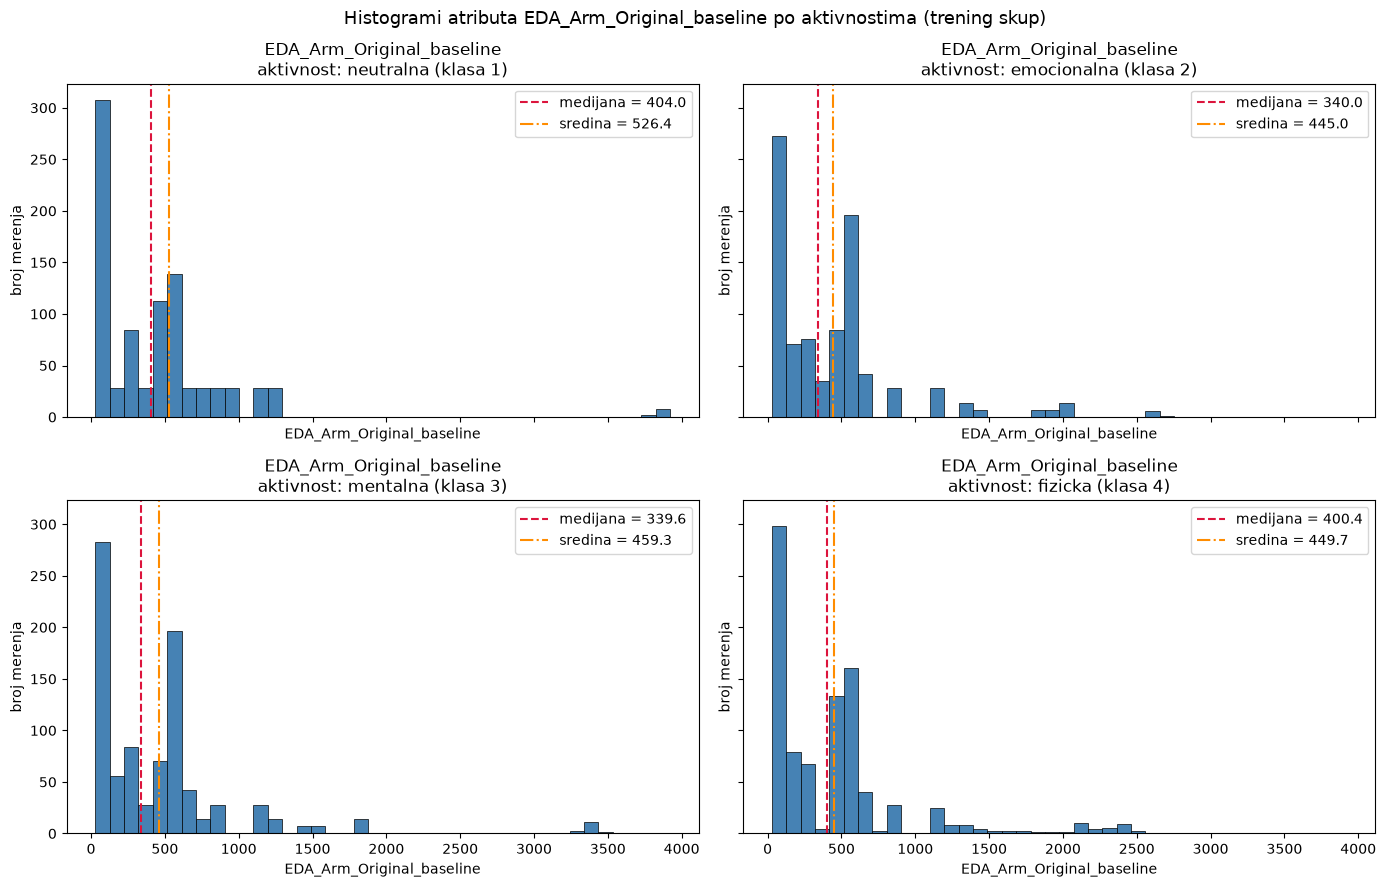

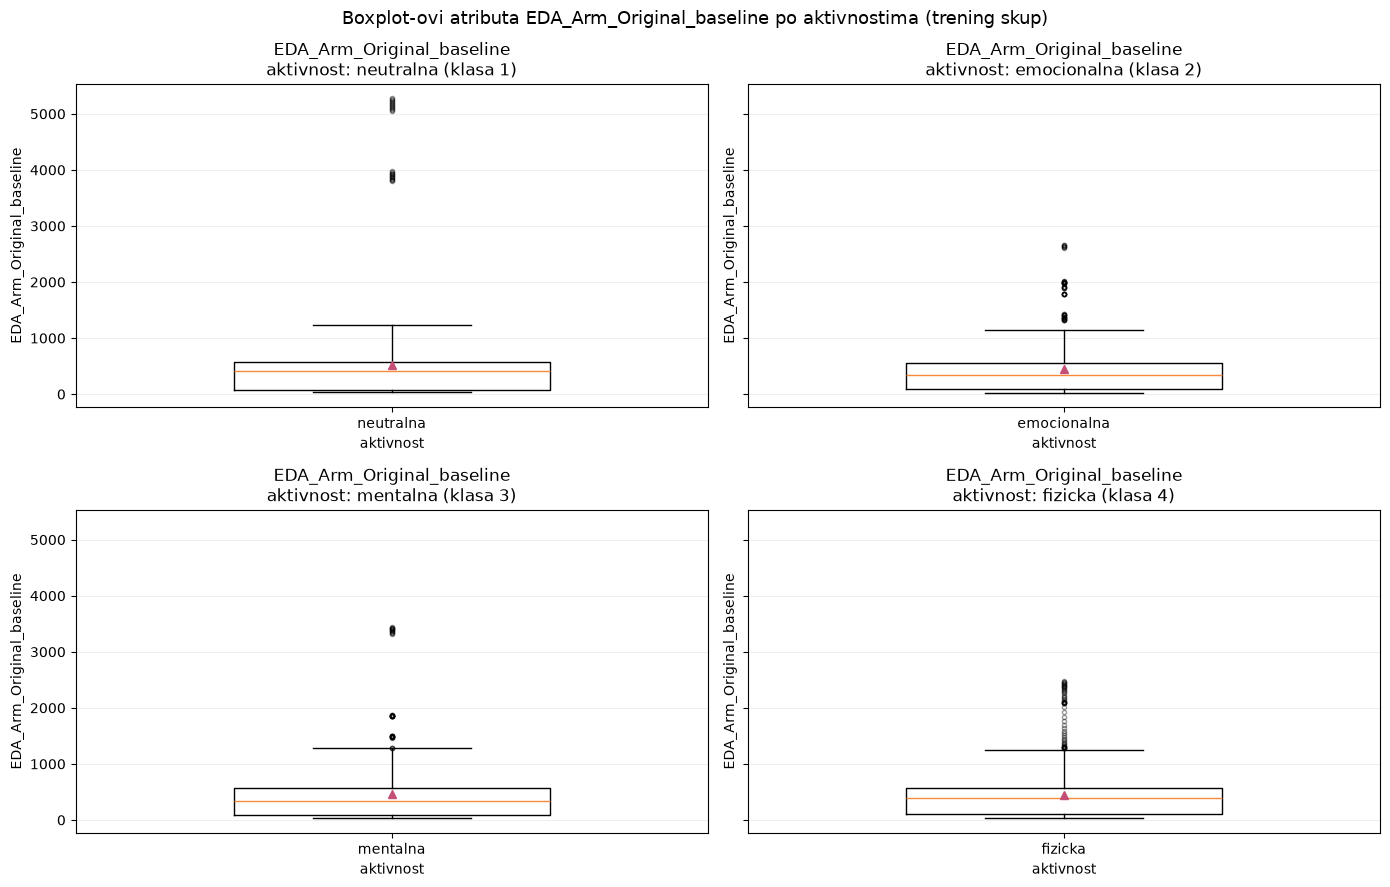

Rezime raspodele atributa EDA_Arm_Original_baseline po aktivnostima: 
             medijana  sredina     std      Q1      Q3     IQR
neutralna      403.96   526.36  796.69   77.31  570.80  493.49
emocionalna    340.05   444.97  451.95   98.75  553.87  455.11
mentalna       339.63   459.30  522.79   95.31  568.42  473.11
fizicka        400.42   449.75  473.65  104.07  563.79  459.72
Razlika najvece i najmanje medijane po klasama:  64.34
Prosecan IQR unutar klase:  470.36
Odnos razlike medijana i prosecnog IQR-a:  0.1368


In [11]:
# Analiza raspodela izabranih atributa po aktivnostima.
# Uzajamna informacija nam kaze samo koliko je atribut informativan (jedan broj), ali ne i kako tacno razdvaja klase - da li jedna aktivnost ima
# pomerenu sredinu, da li se razlikuju po rasipanju, da li postoji preklapanje raspodela. Zato za atribut sa najvecom uzajamnom informacijom
# medju izabranim atributima crtamo histogram i boxplot posebno za svaku od 4 aktivnosti, kako bismo videli da li se raspodele stvarno razdvajaju.
# Sve crtamo iskljucivo nad trening skupom, iz istog razloga kao i kod redukcije dimenzionalnosti - test skup ne smemo ni da gledamo.

import matplotlib.pyplot as plt

ACTIVITY_NAMES = {1: "neutralna", 2: "emocionalna", 3: "mentalna", 4: "fizicka"}

# atribut sa najvecom uzajamnom informacijom medju izabranim atributima
top_feature = mi_scores.loc[selected_features].idxmax()
feature_values = X_train_reduced[top_feature]
activities = sorted(ACTIVITY_NAMES)

print("Atribut sa najvecom uzajamnom informacijom medju izabranim atributima: ", top_feature)
print("Vrednost uzajamne informacije: ", round(float(mi_scores[top_feature]), 4))

# --- Histogrami po aktivnostima ---
# Svi podgrafici moraju da dele iste granice binova i istu skalu na obe ose, inace bi svaki podgrafik imao svoju skalu
# pa bi raspodele izgledale slicnije (ili razlicitije) nego sto stvarno jesu.
# Atribut ima izrazito dug desni rep, pa histogram crtamo na opsegu [0.5, 99.5] percentila - u suprotnom bi nekoliko ekstremnih
# vrednosti razvuklo x-osu i sve ostale vrednosti bi upale u prvih par binova.
lower_bound = feature_values.quantile(0.005)
upper_bound = feature_values.quantile(0.995)
bins = np.linspace(lower_bound, upper_bound, 41)
outside_range = int(((feature_values < lower_bound) | (feature_values > upper_bound)).sum())
print(f"Broj merenja van prikazanog opsega histograma [{lower_bound:.2f}, {upper_bound:.2f}]: {outside_range} od {len(feature_values)}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
for ax, activity in zip(axes.ravel(), activities):
    values = feature_values[y_train == activity]
    ax.hist(values, bins=bins, color="steelblue", edgecolor="black", linewidth=0.5)
    ax.axvline(values.median(), color="crimson", linestyle="--", linewidth=1.5, label=f"medijana = {values.median():.1f}")
    ax.axvline(values.mean(), color="darkorange", linestyle="-.", linewidth=1.5, label=f"sredina = {values.mean():.1f}")
    ax.set_title(f"{top_feature}\naktivnost: {ACTIVITY_NAMES[activity]} (klasa {activity})")
    ax.set_xlabel(top_feature)
    ax.set_ylabel("broj merenja")
    ax.legend()
fig.suptitle(f"Histogrami atributa {top_feature} po aktivnostima (trening skup)", fontsize=13)
fig.tight_layout()
plt.show()

# --- Boxplot-ovi po aktivnostima ---
# Boxplot pokazuje ono sto se sa histograma tesko procita: tacan polozaj medijane, sirinu interkvartilnog raspona (IQR, "kutija" u kojoj je srednjih 50% merenja)
# i koliko ima ekstremnih vrednosti. Takodje delimo y-osu izmedju podgrafika kako bi kutije bile uporedive.
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
for ax, activity in zip(axes.ravel(), activities):
    values = feature_values[y_train == activity]
    ax.boxplot(
        values,
        widths=0.5,
        showmeans=True,
        tick_labels=[ACTIVITY_NAMES[activity]],
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    )
    ax.set_title(f"{top_feature}\naktivnost: {ACTIVITY_NAMES[activity]} (klasa {activity})")
    ax.set_ylabel(top_feature)
    ax.set_xlabel("aktivnost")
    ax.grid(axis="y", alpha=0.3)
fig.suptitle(f"Boxplot-ovi atributa {top_feature} po aktivnostima (trening skup)", fontsize=13)
fig.tight_layout()
plt.show()

# --- Brojcani rezime koji prati grafike ---
# medijana i IQR su otporni na ekstremne vrednosti, pa su ovde informativniji od sredine i standardne devijacije
summary = pd.DataFrame({
    "medijana": feature_values.groupby(y_train).median(),
    "sredina": feature_values.groupby(y_train).mean(),
    "std": feature_values.groupby(y_train).std(),
    "Q1": feature_values.groupby(y_train).quantile(0.25),
    "Q3": feature_values.groupby(y_train).quantile(0.75),
})
summary["IQR"] = summary["Q3"] - summary["Q1"]
summary.index = [ACTIVITY_NAMES[activity] for activity in summary.index]

print("Rezime raspodele atributa", top_feature, "po aktivnostima: ")
print(summary.round(2))

# koliko se medijane klasa uopste razlikuju u odnosu na rasipanje unutar klase - ako je ovaj odnos mali, klase se preklapaju
median_spread = summary["medijana"].max() - summary["medijana"].min()
print("Razlika najvece i najmanje medijane po klasama: ", round(float(median_spread), 2))
print("Prosecan IQR unutar klase: ", round(float(summary["IQR"].mean()), 2))
print("Odnos razlike medijana i prosecnog IQR-a: ", round(float(median_spread / summary["IQR"].mean()), 4))


Udeo varijanse koji dolazi od razlike izmedju ispitanika za EDA_Arm_Original_baseline :  0.8322
Poredjenje po svim izabranim atributima (sortirano po udelu varijanse izmedju ispitanika): 
                           udeo_var_izmedju_ispitanika  MI_sirovo  \
ECG_amplitude_RR_baseline                        0.963      0.835   
ECG_PSD_baseline                                 0.952      0.606   
ECG_HR_min_div_baseline                          0.936      0.668   
EDA_Arm_Original_baseline                        0.832      1.008   
EDA_Hand_Filt2_max                               0.736      0.693   
IT_BRV_baseline                                  0.525      0.661   
EDA_Hand_processed_max                           0.331      0.776   
ECG_amplitude_RR_min                             0.291      0.838   
ECG_amplitude_RR_max                             0.284      0.768   
IT_Original_min                                  0.257      0.716   
IT_BR_mean                                       0.21

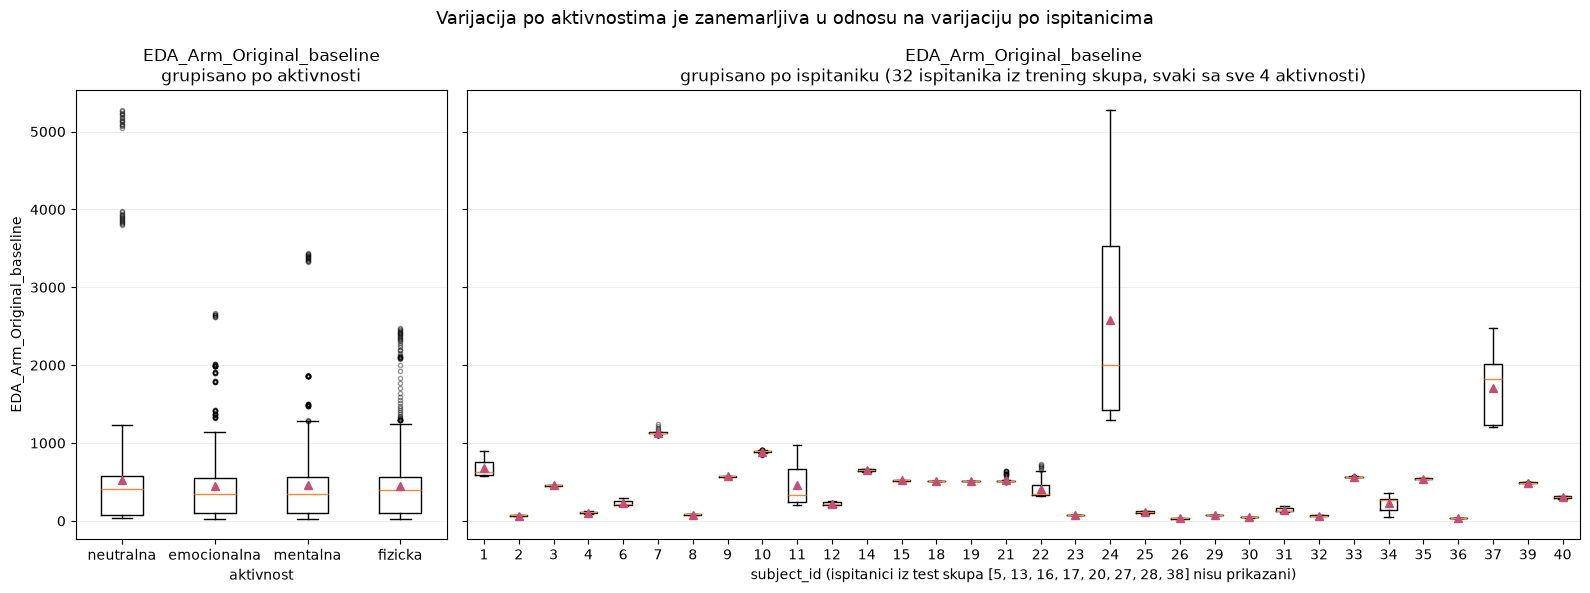

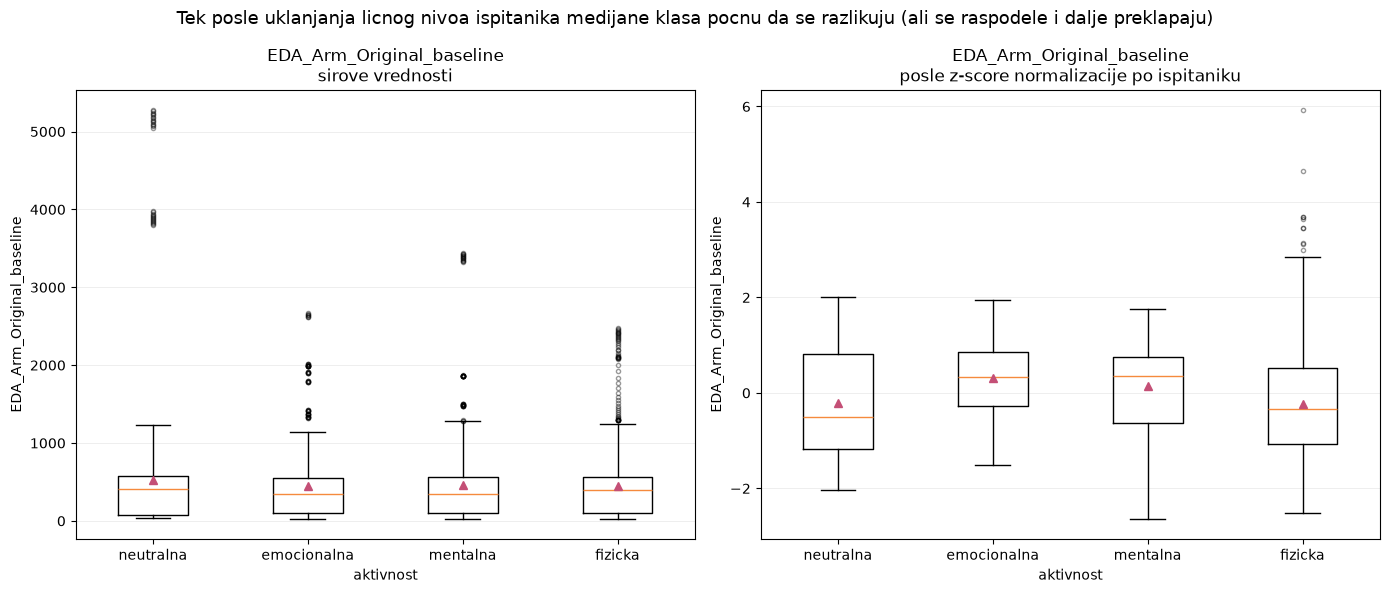

Medijane po aktivnostima posle normalizacije po ispitaniku: 
target
neutralna     -0.499
emocionalna    0.332
mentalna       0.345
fizicka       -0.347
Name: EDA_Arm_Original_baseline, dtype: float64


In [12]:
# Zakljucak iz prethodnog koraka: atribut sa najvecom uzajamnom informacijom (EDA_Arm_Original_baseline, MI = 1.0084) ima gotovo identicne raspodele
# za sve 4 aktivnosti - medijane se razlikuju za 64 jedinice, dok je prosecan IQR unutar klase 470, pa se kutije skoro potpuno preklapaju.
# Deluje kontradiktorno: kako atribut moze da bude najinformativniji po MI, a da vizuelno uopste ne razdvaja klase?
# Hipoteza: MI je ovde naduvan jer varijansa atributa ne dolazi od aktivnosti nego od samog ispitanika (svaki covek ima svoj nivo provodljivosti koze).
# mutual_info_classif koristi ocenu zasnovanu na k najblizih suseda, pa su susedi jednog merenja gotovo uvek merenja istog ispitanika - lokalno, unutar
# jednog ispitanika, aktivnosti se stvarno razlikuju i ocena to pokupi, ali ta razlika nestane kada se svi ispitanici pomesaju u jednu raspodelu.
# U nastavku to proveravamo na tri nacina: dekompozicijom varijanse, poredjenjem MI pre i posle normalizacije po ispitaniku, i graficki.

from itertools import groupby

# --- Dokaz 1: koliki deo varijanse atributa dolazi od razlike izmedju ispitanika, a koliki od merenja unutar istog ispitanika ---
# ukupnu varijansu delimo na deo izmedju ispitanika (varijansa prosekâ po ispitaniku) i ostatak (varijacija unutar ispitanika).
# Ako je udeo izmedju ispitanika blizu 1, atribut prakticno meri "ko je ispitanik", a ne "koju aktivnost radi".
between_subject_share = X_train_reduced[top_feature].groupby(groups_train).mean().var() / X_train_reduced[top_feature].var()
print("Udeo varijanse koji dolazi od razlike izmedju ispitanika za", top_feature, ": ", round(float(between_subject_share), 4))

# --- Dokaz 2: uzajamna informacija pre i posle normalizacije po ispitaniku ---
# Svakom ispitaniku posebno oduzmemo njegov prosek i podelimo njegovom standardnom devijacijom (z-score unutar ispitanika).
# Time uklanjamo licni nivo signala, a ostaje samo relativna promena u odnosu na sopstveni prosek - tacno ono sto bi trebalo da nosi informaciju o aktivnosti.
# Ako MI posle toga naglo padne, znaci da je pre normalizacije MI merila identitet ispitanika, a ne aktivnost.

X_train_normalized = X_train_reduced.groupby(groups_train).transform(lambda values: (values - values.mean()) / values.std())

# MI racunamo nad oba skupa u istom redosledu kolona i sa istim seed-om, kako bi poredjenje bilo posteno
# (mutual_info_classif dodaje mali slucajni sum na atribute, pa se vrednosti mogu neznatno razlikovati od onih iz koraka 2)
mi_raw = pd.Series(mutual_info_classif(X_train_reduced, y_train, random_state=RANDOM_STATE), index=X_train_reduced.columns)
mi_normalized = pd.Series(mutual_info_classif(X_train_normalized, y_train, random_state=RANDOM_STATE), index=X_train_normalized.columns)

variance_summary = pd.DataFrame({
    "udeo_var_izmedju_ispitanika": X_train_reduced.groupby(groups_train).mean().var() / X_train_reduced.var(),
    "MI_sirovo": mi_raw,
    "MI_posle_normalizacije": mi_normalized,
})
variance_summary["odnos_MI"] = variance_summary["MI_posle_normalizacije"] / variance_summary["MI_sirovo"]
variance_summary = variance_summary.sort_values("udeo_var_izmedju_ispitanika", ascending=False)

print("Poredjenje po svim izabranim atributima (sortirano po udelu varijanse izmedju ispitanika): ")
print(variance_summary.round(3))

# Veza nije glatka nego pragovska - MI pada tek kod atributa kod kojih varijansa izmedju ispitanika potpuno dominira,
# dok kod ostalih atributa normalizacija ne smeta, a ponegde cak i pomogne (uklanja se sum vezan za ispitanika).
dominated_by_subject = variance_summary["udeo_var_izmedju_ispitanika"] > 0.8
print("Atributi kod kojih varijansa izmedju ispitanika dominira (udeo > 0.8): ", int(dominated_by_subject.sum()))
print("  prosecan odnos MI posle/pre normalizacije: ", round(float(variance_summary.loc[dominated_by_subject, "odnos_MI"].mean()), 3))
print("Ostali atributi: ", int((~dominated_by_subject).sum()))
print("  prosecan odnos MI posle/pre normalizacije: ", round(float(variance_summary.loc[~dominated_by_subject, "odnos_MI"].mean()), 3))

# --- Dokaz 3 (grafik): ista skala, levo grupisano po aktivnosti, desno po ispitaniku ---
# Ovo je najdirektniji prikaz - ako je hipoteza tacna, kutije po aktivnostima su skoro identicne, a kutije po ispitanicima se drasticno razlikuju.
# Crtamo samo ispitanike iz trening skupa - id-evi na x-osi idu do 40, ali ispitanici iz test skupa nedostaju (rupe u nizu id-eva),
# pa to i eksplicitno ispisujemo da grafik ne bi ostavio utisak da su prikazani svi ispitanici iz dataset-a.
train_subjects = sorted(int(subject) for subject in groups_train.unique())
test_subjects = sorted(int(subject) for subject in groups_test.unique())
print("Ispitanici prikazani na grafiku: ", train_subjects)
print("Broj prikazanih ispitanika: ", len(train_subjects), " od ukupno ", groups.nunique(), " u dataset-u")
print("Ispitanici iz test skupa koji NISU prikazani: ", test_subjects)
print("Provera da nijedan ispitanik iz test skupa nije prikazan: ", len(set(train_subjects) & set(test_subjects)) == 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True, width_ratios=[1, 3])

axes[0].boxplot(
    [X_train_reduced[top_feature][y_train == activity] for activity in activities],
    tick_labels=[ACTIVITY_NAMES[activity] for activity in activities],
    showmeans=True,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
)
axes[0].set_title(f"{top_feature}\ngrupisano po aktivnosti")
axes[0].set_xlabel("aktivnost")
axes[0].set_ylabel(top_feature)
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot(
    [X_train_reduced[top_feature][groups_train == subject] for subject in train_subjects],
    tick_labels=[str(subject) for subject in train_subjects],
    showmeans=True,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
)
axes[1].set_title(f"{top_feature}\ngrupisano po ispitaniku ({len(train_subjects)} ispitanika iz trening skupa, svaki sa sve 4 aktivnosti)")
axes[1].set_xlabel(f"subject_id (ispitanici iz test skupa {test_subjects} nisu prikazani)")
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("Varijacija po aktivnostima je zanemarljiva u odnosu na varijaciju po ispitanicima", fontsize=13)
fig.tight_layout()
plt.show()

# --- Dokaz 4 (grafik): iste kutije po aktivnostima, pre i posle normalizacije po ispitaniku ---
# Levo su sirove vrednosti (kutije se preklapaju), desno vrednosti posle uklanjanja licnog nivoa svakog ispitanika.
# Posle normalizacije se pojavljuje pomeraj medijana izmedju aktivnosti koji je u sirovim podacima bio potpuno zamaskiran,
# ali treba biti realan - raspodele se i dalje znatno preklapaju, pa je i taj ostatak signala slab (MI padne sa 1.008 na 0.297).
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (data_frame, subtitle) in zip(
    axes,
    [(X_train_reduced, "sirove vrednosti"), (X_train_normalized, "posle z-score normalizacije po ispitaniku")],
):
    ax.boxplot(
        [data_frame[top_feature][y_train == activity] for activity in activities],
        tick_labels=[ACTIVITY_NAMES[activity] for activity in activities],
        showmeans=True,
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    )
    ax.set_title(f"{top_feature}\n{subtitle}")
    ax.set_xlabel("aktivnost")
    ax.set_ylabel(top_feature)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Tek posle uklanjanja licnog nivoa ispitanika medijane klasa pocnu da se razlikuju (ali se raspodele i dalje preklapaju)", fontsize=13)
fig.tight_layout()
plt.show()

print("Medijane po aktivnostima posle normalizacije po ispitaniku: ")
print(X_train_normalized[top_feature].groupby(y_train).median().rename(index=ACTIVITY_NAMES).round(3))

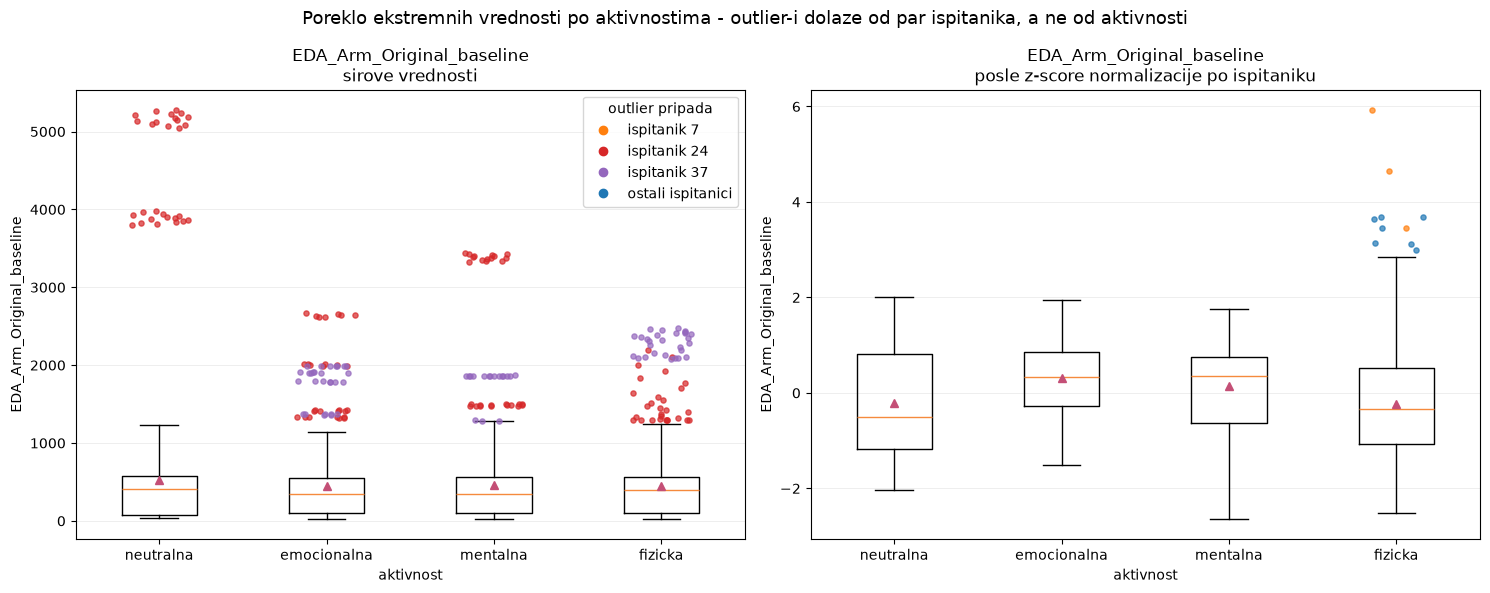

Broj outlier-a po aktivnosti i po ispitaniku od koga poticu: 
                           ukupno_outliera  ispitanik_7  ispitanik_24  \
podaci        aktivnost                                                 
sirovo        neutralna                 28            0            28   
              emocionalna               56            0            28   
              mentalna                  45            0            28   
              fizicka                   56            0            28   
normalizovano neutralna                  0            0             0   
              emocionalna                0            0             0   
              mentalna                   0            0             0   
              fizicka                   10            3             0   

                           ispitanik_37  ostali  
podaci        aktivnost                          
sirovo        neutralna               0       0  
              emocionalna            28       0  
       

In [13]:
# Na prethodnom grafiku se vidi da ispitanici 7, 24 i 37 imaju nivo atributa EDA_Arm_Original_baseline daleko iznad ostalih.
# Postavlja se pitanje da li ekstremne vrednosti (outlier-i) na boxplot-ovima po aktivnostima uopste imaju veze sa aktivnoscu,
# ili su to prosto merenja tih nekoliko ispitanika koji imaju drugaciji nivo signala od svih ostalih.
# Zato ponovo crtamo boxplot-ove po aktivnostima (sirove i normalizovane vrednosti), ali ovaj put tacke outlier-a bojimo u 4 boje:
# posebno ispitanika 7, posebno 24, posebno 37, i jednom bojom sve ostale ispitanike.
# Ako outlier-i dolaze od tih ispitanika, tacke ostalih ispitanika se u sirovim podacima nece ni videti, a posle normalizacije po ispitaniku
# (kada svakom ispitaniku uklonimo njegov licni nivo) outlier-i treba da nestanu jer vise nema ispitanika koji "strci".

from matplotlib.lines import Line2D

HIGHLIGHTED_SUBJECTS = [7, 24, 37]
SUBJECT_COLORS = {7: "tab:orange", 24: "tab:red", 37: "tab:purple"}
OTHER_SUBJECTS_COLOR = "tab:blue"
JITTER_WIDTH = 0.18  # horizontalno rasipanje tacaka, da se preklopljene tacke razdvoje i da se vidi koliko ih zapravo ima


def find_outliers(values):
    # isto pravilo koje matplotlib koristi za boxplot: sve van [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    return values[(values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)]


rng = np.random.default_rng(RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (data_frame, subtitle) in zip(
    axes,
    [(X_train_reduced, "sirove vrednosti"), (X_train_normalized, "posle z-score normalizacije po ispitaniku")],
):
    series = data_frame[top_feature]

    # showfliers=False jer outlier tacke crtamo sami, da bismo mogli da ih obojimo po ispitaniku od koga poticu
    ax.boxplot(
        [series[y_train == activity] for activity in activities],
        tick_labels=[ACTIVITY_NAMES[activity] for activity in activities],
        showmeans=True,
        showfliers=False,
    )

    for position, activity in enumerate(activities, start=1):
        outliers = find_outliers(series[y_train == activity])
        outlier_subjects = groups_train.loc[outliers.index]

        for subject in HIGHLIGHTED_SUBJECTS:
            points = outliers[outlier_subjects == subject]
            ax.scatter(
                position + rng.uniform(-JITTER_WIDTH, JITTER_WIDTH, len(points)),
                points,
                color=SUBJECT_COLORS[subject],
                s=14,
                alpha=0.7,
                zorder=3,
            )

        other_points = outliers[~outlier_subjects.isin(HIGHLIGHTED_SUBJECTS)]
        ax.scatter(
            position + rng.uniform(-JITTER_WIDTH, JITTER_WIDTH, len(other_points)),
            other_points,
            color=OTHER_SUBJECTS_COLOR,
            s=14,
            alpha=0.7,
            zorder=3,
        )

    ax.set_title(f"{top_feature}\n{subtitle}")
    ax.set_xlabel("aktivnost")
    ax.set_ylabel(top_feature)
    ax.grid(axis="y", alpha=0.3)

# legendu pravimo rucno, kako bi se sve 4 kategorije videle i onda kada neka od njih nema nijednu tacku na grafiku
legend_handles = [
    Line2D([], [], marker="o", linestyle="", color=SUBJECT_COLORS[subject], label=f"ispitanik {subject}")
    for subject in HIGHLIGHTED_SUBJECTS
] + [Line2D([], [], marker="o", linestyle="", color=OTHER_SUBJECTS_COLOR, label="ostali ispitanici")]
axes[0].legend(handles=legend_handles, title="outlier pripada", loc="upper right")

fig.suptitle("Poreklo ekstremnih vrednosti po aktivnostima - outlier-i dolaze od par ispitanika, a ne od aktivnosti", fontsize=13)
fig.tight_layout()
plt.show()

# --- Brojcana potvrda onoga sto se vidi na grafiku ---
outlier_rows = []
for data_label, data_frame in [("sirovo", X_train_reduced), ("normalizovano", X_train_normalized)]:
    series = data_frame[top_feature]
    for activity in activities:
        outliers = find_outliers(series[y_train == activity])
        outlier_subjects = groups_train.loc[outliers.index]
        row = {
            "podaci": data_label,
            "aktivnost": ACTIVITY_NAMES[activity],
            "ukupno_outliera": len(outliers),
        }
        for subject in HIGHLIGHTED_SUBJECTS:
            row[f"ispitanik_{subject}"] = int((outlier_subjects == subject).sum())
        row["ostali"] = int((~outlier_subjects.isin(HIGHLIGHTED_SUBJECTS)).sum())
        outlier_rows.append(row)

outlier_summary = pd.DataFrame(outlier_rows).set_index(["podaci", "aktivnost"])
print("Broj outlier-a po aktivnosti i po ispitaniku od koga poticu: ")
print(outlier_summary)

totals = outlier_summary.groupby("podaci").sum()
totals["udeo_od_3_izdvojena_ispitanika"] = (
    totals[[f"ispitanik_{subject}" for subject in HIGHLIGHTED_SUBJECTS]].sum(axis=1) / totals["ukupno_outliera"]
)
print("Ukupno po vrsti podataka: ")
print(totals.round(3))


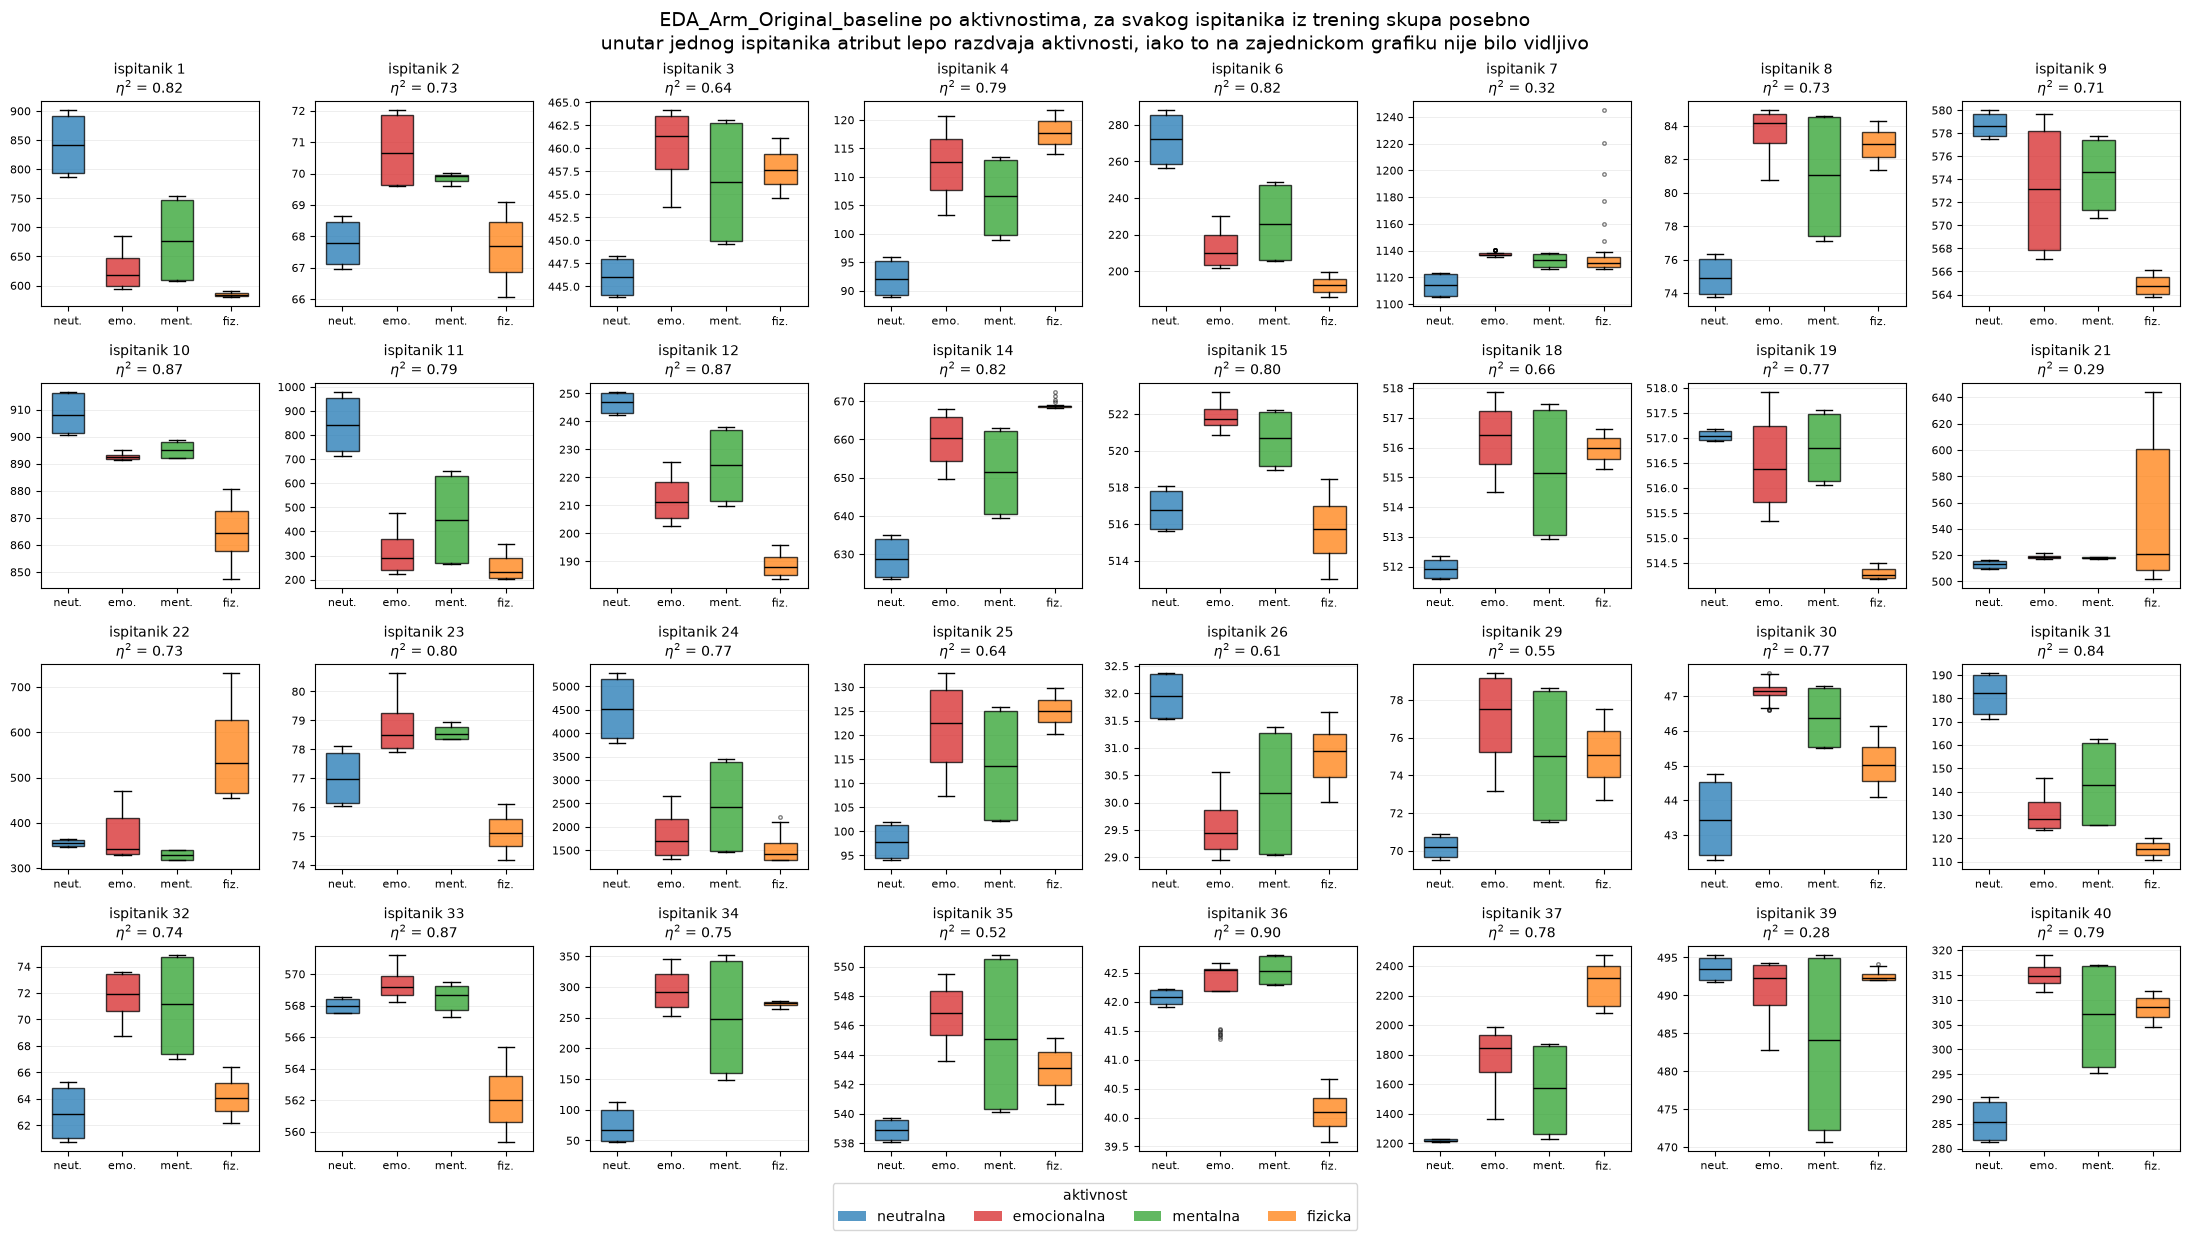

eta^2 po ispitaniku (udeo varijanse atributa koji objasnjava aktivnost): 
1     0.818
2     0.733
3     0.638
4     0.786
6     0.820
7     0.324
8     0.726
9     0.712
10    0.874
11    0.788
12    0.871
14    0.818
15    0.804
18    0.655
19    0.770
21    0.291
22    0.728
23    0.803
24    0.767
25    0.641
26    0.609
29    0.550
30    0.769
31    0.837
32    0.739
33    0.866
34    0.746
35    0.520
36    0.904
37    0.781
39    0.284
40    0.791
Medijana eta^2 po ispitaniku:  0.768
Najmanji eta^2:  0.284  (ispitanik  39 )
Najveci eta^2:  0.9037  (ispitanik  36 )
Broj ispitanika sa eta^2 > 0.5:  29  od  32
eta^2 kada se svi ispitanici posmatraju zajedno:  0.0032
Odnos (medijana po ispitaniku / zajednicki):  237.7 puta


In [14]:
# Do sada smo videli da atribut EDA_Arm_Original_baseline, iako ima najvecu uzajamnu informaciju, ne razdvaja klase kada se svi ispitanici posmatraju zajedno.
# Ovde pokazujemo drugu stranu te iste price: unutar jednog ispitanika taj atribut razdvaja aktivnosti jako dobro.
# Za svakog ispitanika iz trening skupa crtamo poseban podgrafik sa 4 boxplot-a (po jedan za svaku aktivnost), obojena razlicitim bojama.
# Svaki podgrafik ima svoju y-osu, jer je nivo signala licna karakteristika ispitanika i vrednosti se razlikuju za red velicine
# (ispitanik 2 je oko 50, ispitanik 24 oko 2000) - da smo delili y-osu, kod vecine ispitanika bi sve 4 kutije bile spljostene u liniju.
# Zato pored svakog podgrafika ispisujemo i eta^2, meru koliko procenata varijanse atributa kod tog ispitanika objasnjava bas aktivnost.

from matplotlib.patches import Patch

ACTIVITY_PLOT_COLORS = {1: "tab:blue", 2: "tab:red", 3: "tab:green", 4: "tab:orange"}
ACTIVITY_SHORT_NAMES = {1: "neut.", 2: "emo.", 3: "ment.", 4: "fiz."}


def eta_squared(values, labels):
    # udeo varijanse objasnjen pripadnoscu klasi: suma kvadrata izmedju grupa / ukupna suma kvadrata
    # 0 znaci da klase uopste ne razdvajaju vrednosti, 1 znaci savrseno razdvajanje
    grand_mean = values.mean()
    between_groups = sum(
        len(values[labels == activity]) * (values[labels == activity].mean() - grand_mean) ** 2
        for activity in activities
    )
    total = ((values - grand_mean) ** 2).sum()
    return between_groups / total


feature_by_subject = X_train_reduced[top_feature]

# eta^2 racunamo za svakog ispitanika posebno, i za ceo trening skup kada se ispitanici pomesaju
eta_per_subject = pd.Series(
    {
        subject: eta_squared(feature_by_subject[groups_train == subject], y_train[groups_train == subject])
        for subject in train_subjects
    }
)
eta_pooled = eta_squared(feature_by_subject, y_train)

n_columns = 8
n_rows = int(np.ceil(len(train_subjects) / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(22, 3.1 * n_rows))

for ax, subject in zip(axes.ravel(), train_subjects):
    subject_mask = groups_train == subject
    subject_values = feature_by_subject[subject_mask]
    subject_labels = y_train[subject_mask]

    boxes = ax.boxplot(
        [subject_values[subject_labels == activity] for activity in activities],
        tick_labels=[ACTIVITY_SHORT_NAMES[activity] for activity in activities],
        patch_artist=True,
        widths=0.6,
        flierprops={"marker": "o", "markersize": 2.5, "alpha": 0.5},
    )
    for patch, activity in zip(boxes["boxes"], activities):
        patch.set_facecolor(ACTIVITY_PLOT_COLORS[activity])
        patch.set_alpha(0.75)
    for median_line in boxes["medians"]:
        median_line.set_color("black")

    ax.set_title(f"ispitanik {subject}\n" + r"$\eta^2$ = " + f"{eta_per_subject[subject]:.2f}", fontsize=10)
    ax.tick_params(axis="both", labelsize=8)
    ax.grid(axis="y", alpha=0.3)

# ako broj ispitanika nije deljiv brojem kolona, prazne podgrafike sklanjamo da ne ostanu prazni okviri
for ax in axes.ravel()[len(train_subjects):]:
    ax.axis("off")

legend_handles = [
    Patch(facecolor=ACTIVITY_PLOT_COLORS[activity], alpha=0.75, label=ACTIVITY_NAMES[activity])
    for activity in activities
]
fig.legend(handles=legend_handles, title="aktivnost", loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.01))

fig.suptitle(
    f"{top_feature} po aktivnostima, za svakog ispitanika iz trening skupa posebno\n"
    "unutar jednog ispitanika atribut lepo razdvaja aktivnosti, iako to na zajednickom grafiku nije bilo vidljivo",
    fontsize=14,
)
fig.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

# --- Brojcana potvrda: koliko varijanse objasnjava aktivnost unutar ispitanika, a koliko kada se svi pomesaju ---
print("eta^2 po ispitaniku (udeo varijanse atributa koji objasnjava aktivnost): ")
print(eta_per_subject.round(3).to_string())
print("Medijana eta^2 po ispitaniku: ", round(float(eta_per_subject.median()), 4))
print("Najmanji eta^2: ", round(float(eta_per_subject.min()), 4), " (ispitanik ", int(eta_per_subject.idxmin()), ")")
print("Najveci eta^2: ", round(float(eta_per_subject.max()), 4), " (ispitanik ", int(eta_per_subject.idxmax()), ")")
print("Broj ispitanika sa eta^2 > 0.5: ", int((eta_per_subject > 0.5).sum()), " od ", len(train_subjects))
print("eta^2 kada se svi ispitanici posmatraju zajedno: ", round(float(eta_pooled), 4))
print("Odnos (medijana po ispitaniku / zajednicki): ", round(float(eta_per_subject.median() / eta_pooled), 1), "puta")


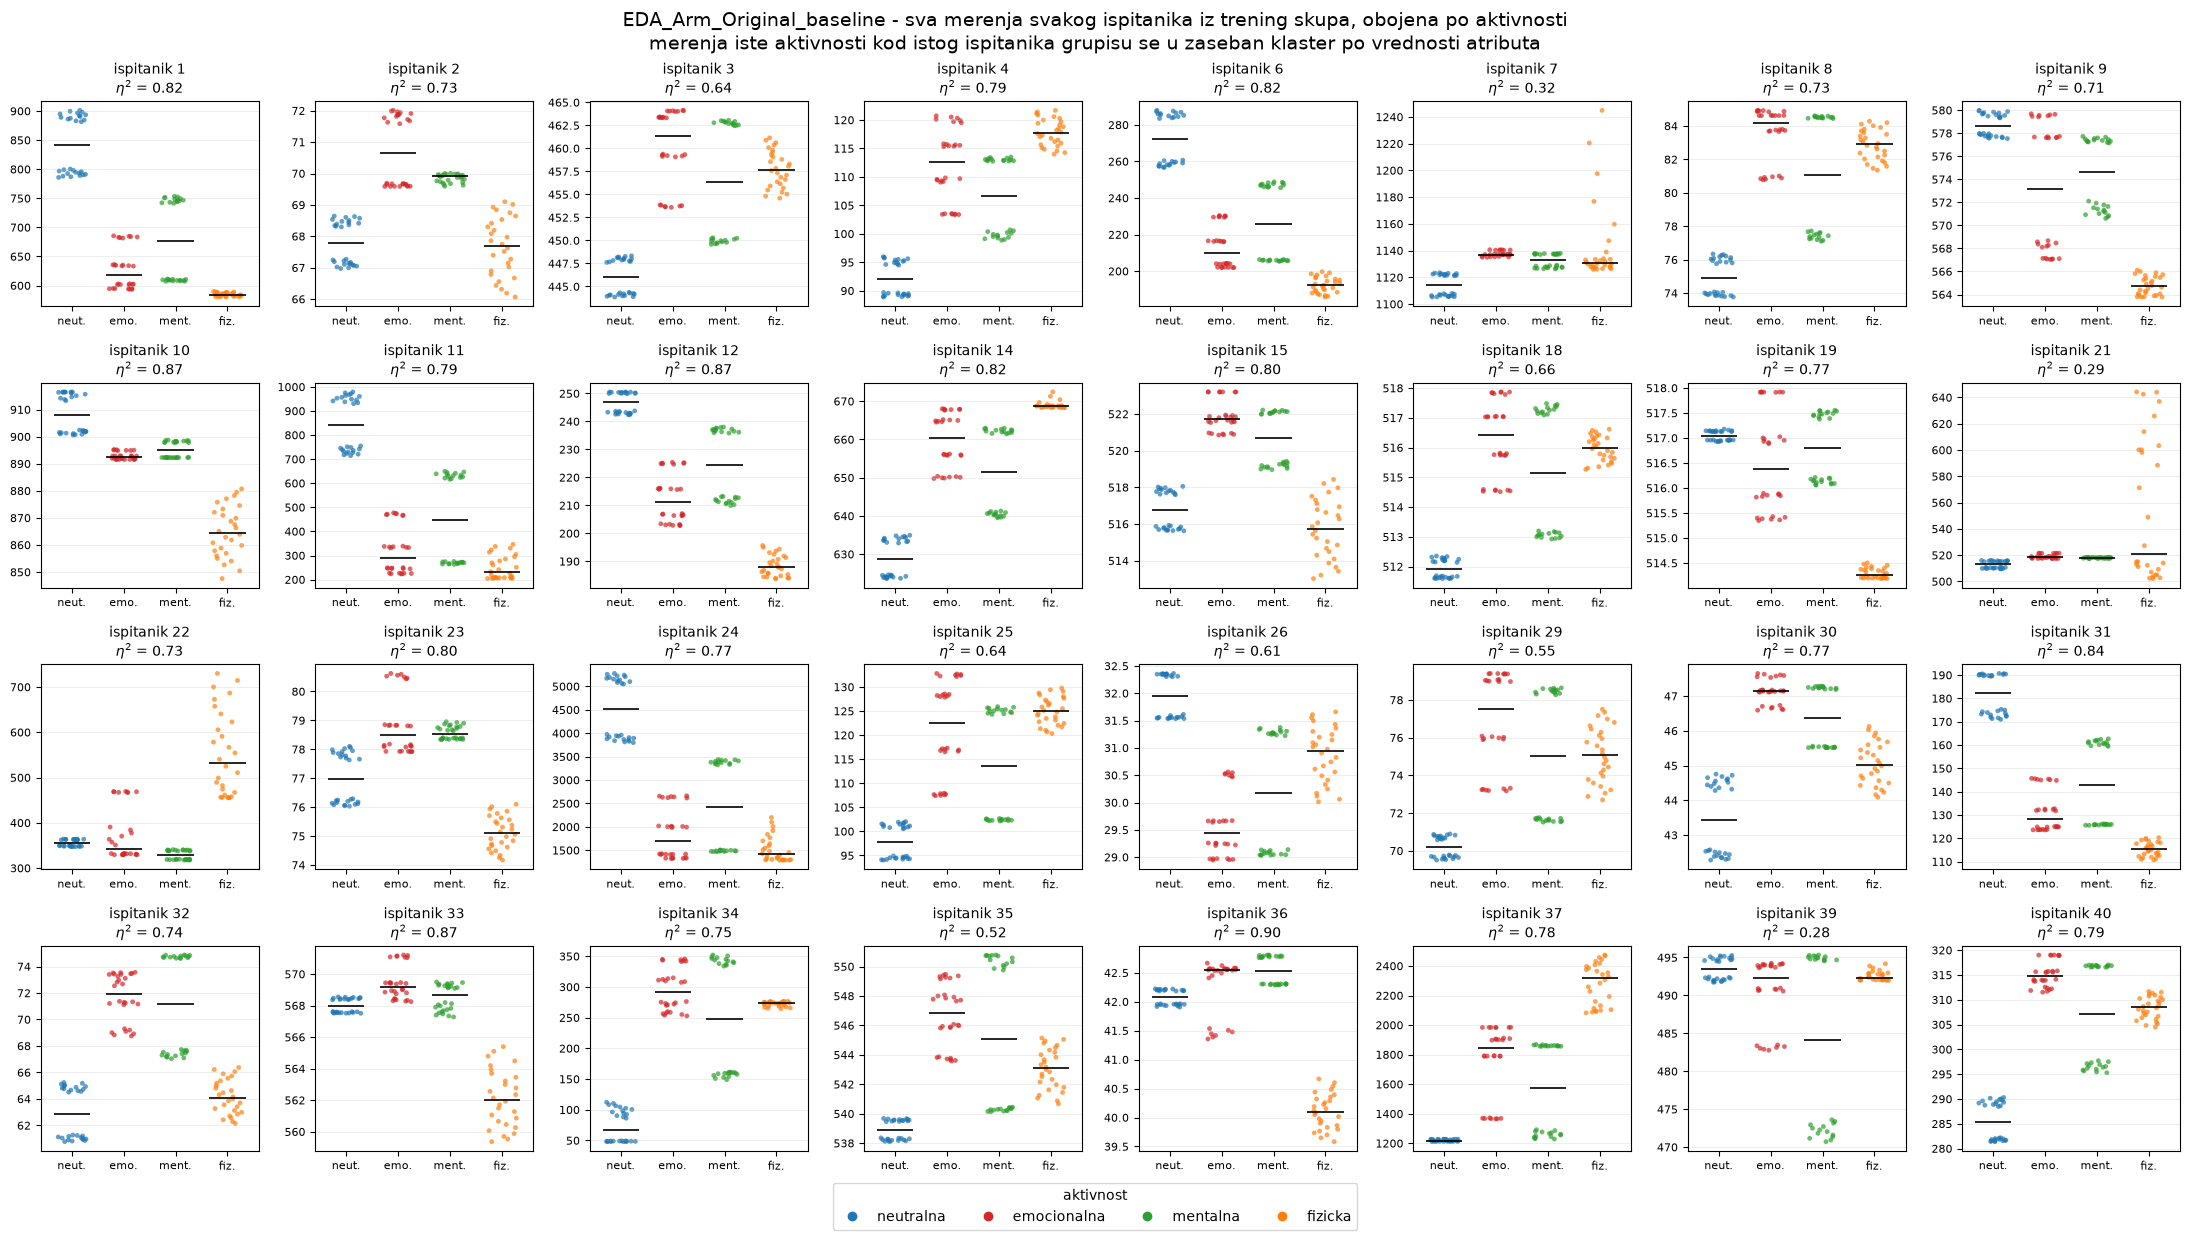

Kvalitet klastera po ispitaniku: 
     eta2  tacnost_1NN
1   0.818        1.000
2   0.733        0.750
3   0.638        0.946
4   0.786        0.812
6   0.820        1.000
7   0.324        0.670
8   0.726        0.946
9   0.712        0.714
10  0.874        1.000
11  0.788        0.848
12  0.871        1.000
14  0.818        1.000
15  0.804        0.866
18  0.655        0.946
19  0.770        0.946
21  0.291        0.848
22  0.728        0.911
23  0.803        0.839
24  0.767        0.839
25  0.641        0.777
26  0.609        0.777
29  0.550        0.911
30  0.769        0.741
31  0.837        1.000
32  0.739        0.866
33  0.866        0.795
34  0.746        0.759
35  0.520        0.938
36  0.904        1.000
37  0.781        0.991
39  0.284        0.571
40  0.791        0.964
Medijana 1-NN tacnosti po ispitaniku:  0.8885
Najmanja 1-NN tacnost:  0.571  (ispitanik  39 )
Broj ispitanika sa 1-NN tacnoscu preko 0.8:  23  od  32
Tacnost slucajnog pogadjanja za 4 balansirane klase: 0.25

In [15]:
# Isti prikaz kao u prethodnoj celiji, samo sto umesto boxplot-a crtamo pojedinacna merenja kao tacke (scatter), obojene po aktivnosti.
# Boxplot pokazuje samo sazetak raspodele (medijanu, kvartile), pa se ne vidi koliko merenja stvarno ima u svakoj grupi
# niti da li se tacke dve aktivnosti mesaju ili su lepo razdvojene. Na scatter-u se vidi svako od 112 merenja ispitanika.
# Tacke horizontalno rasipamo (jitter) jer bi inace svih 28 merenja jedne aktivnosti palo na istu vertikalnu liniju i preklopilo se.
# Cilj je da se vidi da merenja iste aktivnosti kod istog ispitanika grade zaseban klaster po visini (po vrednosti atributa).

STRIP_JITTER_WIDTH = 0.28

rng = np.random.default_rng(RANDOM_STATE)

fig, axes = plt.subplots(n_rows, n_columns, figsize=(22, 3.1 * n_rows))

for ax, subject in zip(axes.ravel(), train_subjects):
    subject_mask = groups_train == subject
    subject_values = feature_by_subject[subject_mask]
    subject_labels = y_train[subject_mask]

    for position, activity in enumerate(activities, start=1):
        points = subject_values[subject_labels == activity]
        ax.scatter(
            position + rng.uniform(-STRIP_JITTER_WIDTH, STRIP_JITTER_WIDTH, len(points)),
            points,
            color=ACTIVITY_PLOT_COLORS[activity],
            s=12,
            alpha=0.7,
            edgecolors="none",
        )
        # crna crta na nivou medijane, kao orijentir gde je centar klastera
        ax.hlines(points.median(), position - 0.35, position + 0.35, color="black", linewidth=1.2, zorder=3)

    ax.set_xticks(activities)
    ax.set_xticklabels([ACTIVITY_SHORT_NAMES[activity] for activity in activities])
    ax.set_xlim(0.4, len(activities) + 0.6)
    ax.set_title(f"ispitanik {subject}\n" + r"$\eta^2$ = " + f"{eta_per_subject[subject]:.2f}", fontsize=10)
    ax.tick_params(axis="both", labelsize=8)
    ax.grid(axis="y", alpha=0.3)

for ax in axes.ravel()[len(train_subjects):]:
    ax.axis("off")

legend_handles = [
    Line2D([], [], marker="o", linestyle="", color=ACTIVITY_PLOT_COLORS[activity], label=ACTIVITY_NAMES[activity])
    for activity in activities
]
fig.legend(handles=legend_handles, title="aktivnost", loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.01))

fig.suptitle(
    f"{top_feature} - sva merenja svakog ispitanika iz trening skupa, obojena po aktivnosti\n"
    "merenja iste aktivnosti kod istog ispitanika grupisu se u zaseban klaster po vrednosti atributa",
    fontsize=14,
)
fig.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

# --- Brojcana provera koliko su klasteri stvarno razdvojeni ---
# Za svako merenje jednog ispitanika trazimo njemu najblize merenje po vrednosti atributa (kod istog ispitanika, bez sebe samog)
# i gledamo da li je ono iz iste aktivnosti. To je 1-NN tacnost sa izbacivanjem jednog merenja (leave-one-out) i direktno meri
# ono sto se vidi na grafiku - da li su merenja iste aktivnosti stvarno grupisana. Slucajno pogadjanje bi dalo 0.25 (4 balansirane klase).
# Namerno ne merimo preklapanje preko opsega [min, max] po klasi, jer je taj opseg osetljiv na jednu jedinu ekstremnu tacku
# koja onda "proguta" citav klaster druge aktivnosti, pa bi mera izgledala mnogo losije nego sto grafik pokazuje.
def nearest_neighbour_accuracy(values, labels):
    values_array = values.to_numpy()
    labels_array = labels.to_numpy()
    distances = np.abs(values_array[:, None] - values_array[None, :])
    np.fill_diagonal(distances, np.inf)  # merenje ne sme da bude sam sebi najblizi sused
    nearest = distances.argmin(axis=1)
    return float((labels_array[nearest] == labels_array).mean())


cluster_quality = pd.DataFrame(
    {
        "eta2": eta_per_subject.round(3),
        "tacnost_1NN": pd.Series(
            {
                subject: round(
                    nearest_neighbour_accuracy(
                        feature_by_subject[groups_train == subject], y_train[groups_train == subject]
                    ),
                    3,
                )
                for subject in train_subjects
            }
        ),
    }
)

print("Kvalitet klastera po ispitaniku: ")
print(cluster_quality.to_string())
print("Medijana 1-NN tacnosti po ispitaniku: ", round(float(cluster_quality["tacnost_1NN"].median()), 4))
print("Najmanja 1-NN tacnost: ", round(float(cluster_quality["tacnost_1NN"].min()), 4),
      " (ispitanik ", int(cluster_quality["tacnost_1NN"].idxmin()), ")")
print("Broj ispitanika sa 1-NN tacnoscu preko 0.8: ", int((cluster_quality["tacnost_1NN"] > 0.8).sum()),
      " od ", len(train_subjects))
print("Tacnost slucajnog pogadjanja za 4 balansirane klase: 0.25")


Atribut sa najvecom uzajamnom informacijom na normalizovanim podacima:  IT_BRV_baseline
Njegov MI na normalizovanim podacima:  1.134
Njegov MI na sirovim podacima:  0.6606
Udeo varijanse koji dolazi od razlike izmedju ispitanika:  0.5253


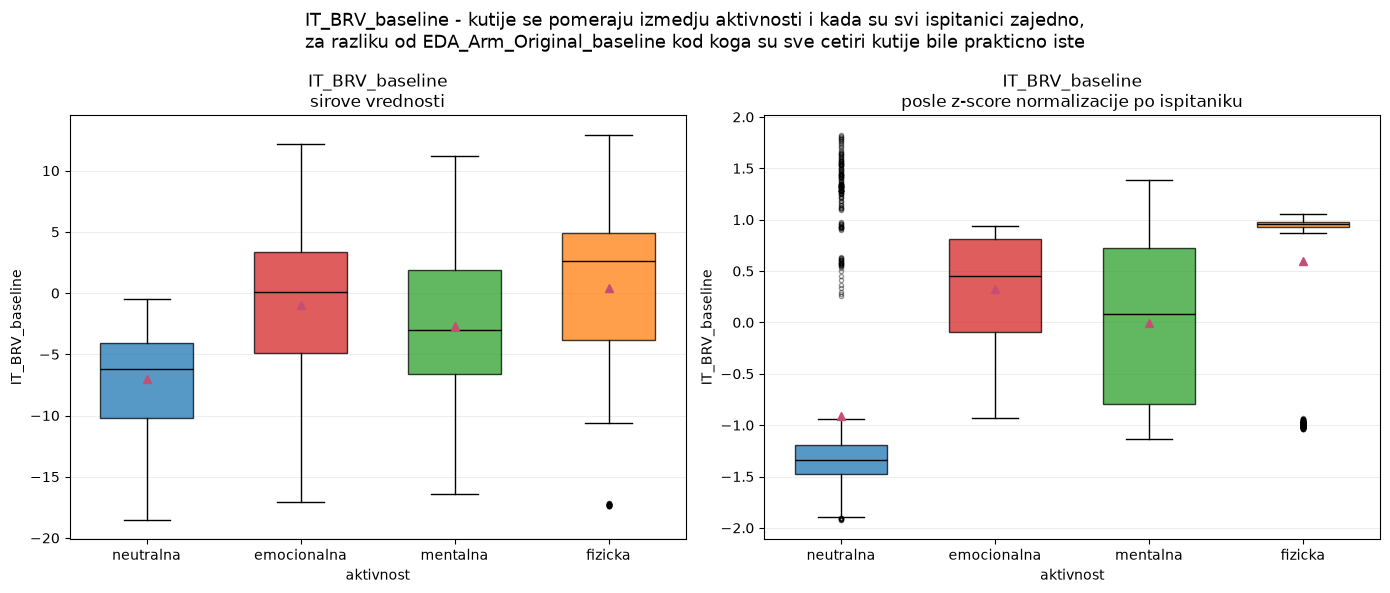

Rezime po aktivnostima (sirove vrednosti): 
             medijana  sredina      Q1     Q3    IQR
neutralna      -6.215   -6.999 -10.177 -4.087  6.090
emocionalna     0.078   -0.973  -4.894  3.348  8.242
mentalna       -3.052   -2.722  -6.635  1.892  8.527
fizicka         2.584    0.440  -3.847  4.931  8.778
Rezime po aktivnostima (normalizovane vrednosti): 
             medijana  sredina     Q1     Q3    IQR
neutralna      -1.339   -0.912 -1.478 -1.196  0.281
emocionalna     0.450    0.326 -0.094  0.814  0.909
mentalna        0.083   -0.010 -0.794  0.722  1.516
fizicka         0.956    0.597  0.925  0.977  0.053
Poredjenje atributa koji je najbolji po MI na normalizovanim i na sirovim podacima: 
                           MI_sirovo  MI_normalizovano  eta2_globalno_sirovo  eta2_globalno_normalizovano  eta2_po_ispitaniku_medijana
atribut                                                                                                                               
IT_BRV_baseline          

In [16]:
# Posle normalizacije po ispitaniku ponovo smo racunali uzajamnu informaciju izabranih atributa, i redosled atributa po MI se promenio.
# Sada najveci MI ima IT_BRV_baseline (bazna vrednost varijabilnosti disanja), a ne EDA_Arm_Original_baseline.
# To je bitna razlika: EDA_Arm_Original_baseline je imao visok MI zato sto je pratio ko je ispitanik, pa je razdvajao aktivnosti samo unutar ispitanika,
# dok atribut sa visokim MI na normalizovanim podacima treba da razdvaja aktivnosti i globalno, kada se svi ispitanici posmatraju zajedno.
# Zato ovde crtamo boxplot-ove atributa IT_BRV_baseline po aktivnostima, i to i za sirove i za normalizovane vrednosti,
# pa isti racun (eta^2) uporedjujemo sa atributom EDA_Arm_Original_baseline iz prethodnih celija.

top_feature_normalized = mi_normalized.idxmax()

print("Atribut sa najvecom uzajamnom informacijom na normalizovanim podacima: ", top_feature_normalized)
print("Njegov MI na normalizovanim podacima: ", round(float(mi_normalized[top_feature_normalized]), 4))
print("Njegov MI na sirovim podacima: ", round(float(mi_raw[top_feature_normalized]), 4))
print("Udeo varijanse koji dolazi od razlike izmedju ispitanika: ",
      round(float(X_train_reduced[top_feature_normalized].groupby(groups_train).mean().var()
                  / X_train_reduced[top_feature_normalized].var()), 4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (data_frame, subtitle) in zip(
    axes,
    [(X_train_reduced, "sirove vrednosti"), (X_train_normalized, "posle z-score normalizacije po ispitaniku")],
):
    series = data_frame[top_feature_normalized]

    boxes = ax.boxplot(
        [series[y_train == activity] for activity in activities],
        tick_labels=[ACTIVITY_NAMES[activity] for activity in activities],
        patch_artist=True,
        showmeans=True,
        widths=0.6,
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    )
    for patch, activity in zip(boxes["boxes"], activities):
        patch.set_facecolor(ACTIVITY_PLOT_COLORS[activity])
        patch.set_alpha(0.75)
    for median_line in boxes["medians"]:
        median_line.set_color("black")

    ax.set_title(f"{top_feature_normalized}\n{subtitle}")
    ax.set_xlabel("aktivnost")
    ax.set_ylabel(top_feature_normalized)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    f"{top_feature_normalized} - kutije se pomeraju izmedju aktivnosti i kada su svi ispitanici zajedno,\n"
    "za razliku od EDA_Arm_Original_baseline kod koga su sve cetiri kutije bile prakticno iste",
    fontsize=13,
)
fig.tight_layout()
plt.show()

# --- Brojcani rezime po aktivnostima ---
for data_label, data_frame in [("sirove vrednosti", X_train_reduced), ("normalizovane vrednosti", X_train_normalized)]:
    series = data_frame[top_feature_normalized]
    class_summary = pd.DataFrame({
        "medijana": series.groupby(y_train).median(),
        "sredina": series.groupby(y_train).mean(),
        "Q1": series.groupby(y_train).quantile(0.25),
        "Q3": series.groupby(y_train).quantile(0.75),
    })
    class_summary["IQR"] = class_summary["Q3"] - class_summary["Q1"]
    class_summary.index = [ACTIVITY_NAMES[activity] for activity in class_summary.index]
    print(f"Rezime po aktivnostima ({data_label}): ")
    print(class_summary.round(3))

# --- Poredjenje sa atributom koji je bio najbolji po MI na sirovim podacima ---
# eta^2 racunamo na dva nacina: globalno (svi ispitanici zajedno) i unutar svakog ispitanika posebno.
# Atribut koji razdvaja klase samo unutar ispitanika ima globalni eta^2 blizu nule, a atribut koji razdvaja i globalno ima osetno veci.
comparison_rows = []
for feature in [top_feature_normalized, top_feature]:
    raw_series = X_train_reduced[feature]
    normalized_series = X_train_normalized[feature]
    per_subject = pd.Series({
        subject: eta_squared(raw_series[groups_train == subject], y_train[groups_train == subject])
        for subject in train_subjects
    })
    comparison_rows.append({
        "atribut": feature,
        "MI_sirovo": round(float(mi_raw[feature]), 3),
        "MI_normalizovano": round(float(mi_normalized[feature]), 3),
        "eta2_globalno_sirovo": round(float(eta_squared(raw_series, y_train)), 4),
        "eta2_globalno_normalizovano": round(float(eta_squared(normalized_series, y_train)), 4),
        "eta2_po_ispitaniku_medijana": round(float(per_subject.median()), 4),
    })

comparison = pd.DataFrame(comparison_rows).set_index("atribut")
print("Poredjenje atributa koji je najbolji po MI na normalizovanim i na sirovim podacima: ")
print(comparison.to_string())

ratio_raw = comparison.loc[top_feature_normalized, "eta2_globalno_sirovo"] / comparison.loc[top_feature, "eta2_globalno_sirovo"]
print("Odnos globalnih eta^2 na sirovim podacima: ", round(float(ratio_raw), 1), "puta u korist", top_feature_normalized)

# Zakljucak koji se vidi iz brojeva: oba atributa dobro razdvajaju aktivnosti unutar jednog ispitanika (medijana eta^2 oko 0.8),
# ali samo IT_BRV_baseline zadrzava deo tog razdvajanja i kada se svi ispitanici pomesaju.
# Treba biti realan - globalni eta^2 od 0.20 (odnosno 0.33 posle normalizacije) znaci da se klase i dalje delimicno preklapaju,
# pa jedan atribut nije dovoljan za klasifikaciju, ali je to kvalitativno drugacije od atributa cije je globalno razdvajanje prakticno nula.


Broj merenja koja su proglasena outlier-om, po ispitaniku (od po 28 merenja svake aktivnosti): 
            neutralna  fizicka  obe_aktivnosti
subject_id                                    
4                  28       28              56
6                  28       28              56
15                 28       28              56
18                 28       28              56
39                 28       28              56
22                 28       28              56
2                   9        0               9
7                   0        0               0
9                   0        0               0
8                   0        0               0
10                  0        0               0
11                  0        0               0
14                  0        0               0
12                  0        0               0
3                   0        0               0
1                   0        0               0
21                  0        0               0
19         

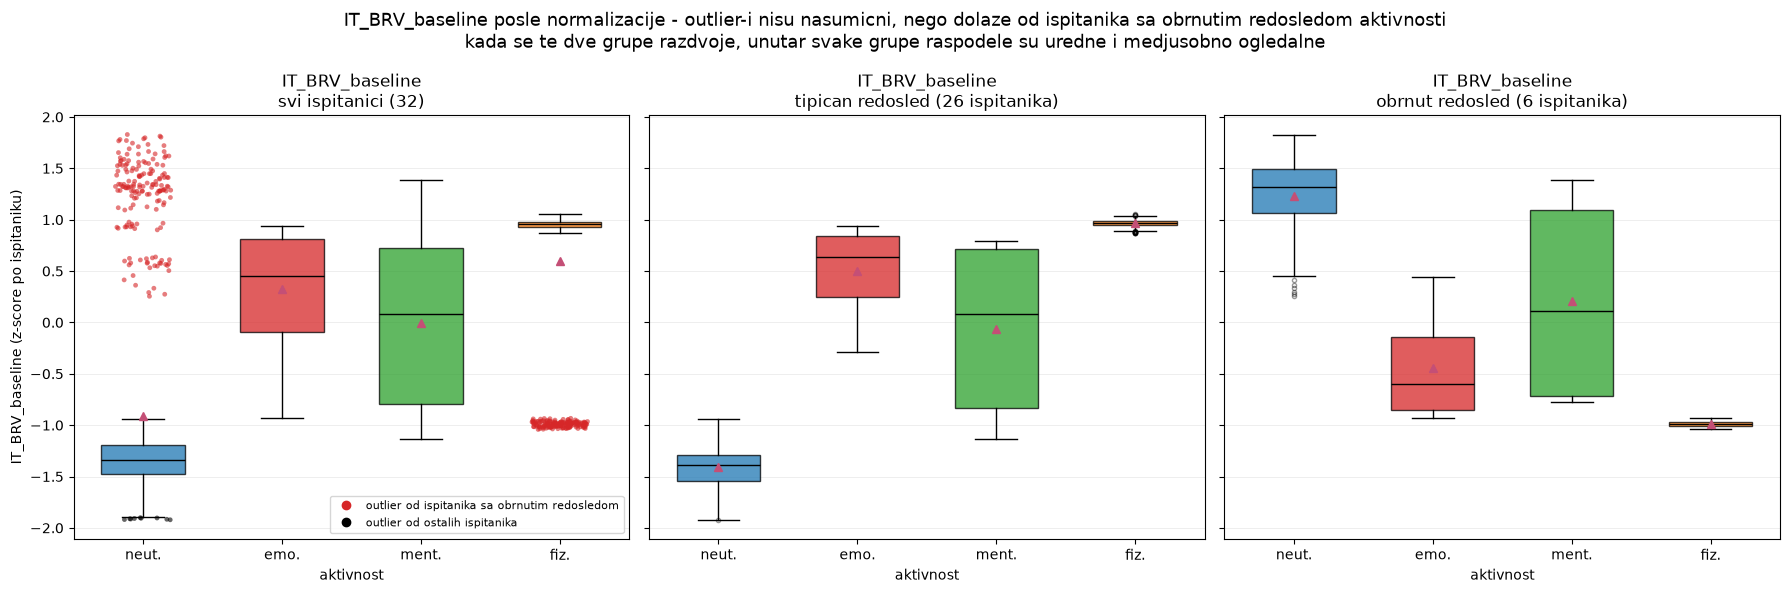

In [17]:
# Na boxplot-u atributa IT_BRV_baseline posle normalizacije po ispitaniku pojavljuje se veliki broj outlier-a za neutralnu (i za fizicku) aktivnost,
# kojih u sirovim podacima uopste nije bilo. Ovde objasnjavamo odakle dolaze.
# Razlog je dvostruk:
#   1) Pravilo za outlier ([Q1 - 1.5*IQR, Q3 + 1.5*IQR]) je relativno u odnosu na rasipanje bas te klase. Normalizacija je rasipanje unutar klase
#      drasticno smanjila (kod neutralne sa IQR 6.09 na 0.28), pa se i "ograda" za outlier-e suzila desetak puta. Ista merenja koja su u sirovim
#      podacima bila duboko unutar siroke ograde, sada ispadaju napolje.
#   2) Rasipanje je tako malo zato sto je vrednost atributa unutar jednog ispitanika skoro odredjena time koja je aktivnost u pitanju (eta^2 oko 0.8),
#      pa z-score preslikava svakog ispitanika na skoro iste cetiri vrednosti. Ali to vazi samo za vecinu ispitanika - kod manjine je redosled
#      aktivnosti obrnut, pa oni posle normalizacije padaju daleko od te uske grupe i budu proglaseni outlier-ima.
# Dakle normalizacija nije napravila outlier-e, nego je uklonila razlike u nivou izmedju ispitanika i time otkrila podgrupu ispitanika
# koja je i ranije postojala, samo je bila sakrivena.

# --- Podela ispitanika na dve grupe, na osnovu podataka a ne rucno ---
# Kod tipicnog ispitanika neutralna aktivnost ima najnizu, a fizicka najvisu vrednost atributa.
# Ispitanika kod koga je taj odnos obrnut (prosecan z za neutralnu veci od proseka za fizicku) svrstavamo u grupu "obrnut redosled".
normalized_feature = X_train_normalized[top_feature_normalized]

# --- Brojcani pregled: koliko merenja svakog ispitanika je proglaseno outlier-om ---
# Outlier-i se pojavljuju samo kod neutralne i fizicke aktivnosti, pa brojimo koliko ih svaki ispitanik daje u jednoj, koliko u drugoj,
# i koliko ukupno (jedno merenje pripada tacno jednoj aktivnosti, pa je kolona "obe_aktivnosti" zbir prethodne dve).
# Svaki ispitanik ima po 28 merenja svake aktivnosti, pa je 28 maksimum po koloni.
neutral_outlier_subjects = groups_train.loc[find_outliers(normalized_feature[y_train == 1]).index]
physical_outlier_subjects = groups_train.loc[find_outliers(normalized_feature[y_train == 4]).index]

outliers_per_subject = pd.DataFrame(
    {
        "neutralna": neutral_outlier_subjects.value_counts(),
        "fizicka": physical_outlier_subjects.value_counts(),
    },
    index=train_subjects,
).fillna(0).astype(int)
outliers_per_subject["obe_aktivnosti"] = outliers_per_subject["neutralna"] + outliers_per_subject["fizicka"]
outliers_per_subject.index.name = "subject_id"

print("Broj merenja koja su proglasena outlier-om, po ispitaniku (od po 28 merenja svake aktivnosti): ")
print(outliers_per_subject.sort_values("obe_aktivnosti", ascending=False).to_string())
print("Ukupno outliera - neutralna: ", int(outliers_per_subject["neutralna"].sum()),
      ", fizicka: ", int(outliers_per_subject["fizicka"].sum()))
print("Broj ispitanika koji uopste imaju outlier-e: ", int((outliers_per_subject["obe_aktivnosti"] > 0).sum()),
      " od ", len(train_subjects))
print("Broj ispitanika koji imaju outlier-e i za neutralnu i za fizicku aktivnost: ",
      int(((outliers_per_subject["neutralna"] > 0) & (outliers_per_subject["fizicka"] > 0)).sum()))

mean_z_by_subject_and_activity = normalized_feature.groupby([groups_train, y_train]).mean().unstack()
mean_z_by_subject_and_activity.columns = [ACTIVITY_NAMES[activity] for activity in mean_z_by_subject_and_activity.columns]

is_flipped = mean_z_by_subject_and_activity[ACTIVITY_NAMES[1]] > mean_z_by_subject_and_activity[ACTIVITY_NAMES[4]]
flipped_subjects = sorted(int(subject) for subject in is_flipped.index[is_flipped])
typical_subjects = sorted(int(subject) for subject in is_flipped.index[~is_flipped])

subject_table = mean_z_by_subject_and_activity.round(3)
subject_table["grupa"] = np.where(is_flipped, "obrnut redosled", "tipican")
subject_table = subject_table.sort_values(["grupa", ACTIVITY_NAMES[1]])

print("Prosecna z-vrednost atributa", top_feature_normalized, "po ispitaniku i aktivnosti: ")
print(subject_table.to_string())
print("Ispitanici sa obrnutim redosledom: ", flipped_subjects, f" ({len(flipped_subjects)} od {len(train_subjects)})")

print("Prosek po grupama: ")
group_profile = subject_table.groupby("grupa")[[ACTIVITY_NAMES[activity] for activity in activities]].mean()
print(group_profile.round(3).to_string())

# --- Poreklo outlier-a po grupama ispitanika ---
origin_rows = []
for activity in activities:
    outliers = find_outliers(normalized_feature[y_train == activity])
    outlier_subjects = groups_train.loc[outliers.index]
    origin_rows.append({
        "aktivnost": ACTIVITY_NAMES[activity],
        "ukupno_outliera": len(outliers),
        "od_obrnutih": int(outlier_subjects.isin(flipped_subjects).sum()),
        "od_tipicnih": int((~outlier_subjects.isin(flipped_subjects)).sum()),
    })
print("Od koje grupe ispitanika poticu outlier-i (normalizovani podaci): ")
print(pd.DataFrame(origin_rows).set_index("aktivnost").to_string())

# --- Grafik: sve zajedno, pa svaka grupa posebno ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

panels = [
    (train_subjects, f"svi ispitanici ({len(train_subjects)})", True),
    (typical_subjects, f"tipican redosled ({len(typical_subjects)} ispitanika)", False),
    (flipped_subjects, f"obrnut redosled ({len(flipped_subjects)} ispitanika)", False),
]

for ax, (subjects_in_panel, subtitle, draw_fences) in zip(axes, panels):
    panel_mask = groups_train.isin(subjects_in_panel)
    panel_values = normalized_feature[panel_mask]
    panel_labels = y_train[panel_mask]

    boxes = ax.boxplot(
        [panel_values[panel_labels == activity] for activity in activities],
        tick_labels=[ACTIVITY_SHORT_NAMES[activity] for activity in activities],
        patch_artist=True,
        showmeans=True,
        widths=0.6,
        showfliers=not draw_fences,
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    )
    for patch, activity in zip(boxes["boxes"], activities):
        patch.set_facecolor(ACTIVITY_PLOT_COLORS[activity])
        patch.set_alpha(0.75)
    for median_line in boxes["medians"]:
        median_line.set_color("black")

    # na prvom panelu outlier tacke crtamo sami i bojimo ih po grupi ispitanika, da se vidi da nisu nasumicne
    if draw_fences:
        for position, activity in enumerate(activities, start=1):
            outliers = find_outliers(panel_values[panel_labels == activity])
            outlier_subjects = groups_train.loc[outliers.index]
            for subject_group, color, label in [
                (flipped_subjects, "tab:red", "obrnut redosled"),
                (typical_subjects, "black", "tipican redosled"),
            ]:
                points = outliers[outlier_subjects.isin(subject_group)]
                ax.scatter(
                    position + rng.uniform(-0.2, 0.2, len(points)),
                    points,
                    color=color,
                    s=12,
                    alpha=0.6,
                    edgecolors="none",
                    zorder=3,
                )

    ax.set_title(f"{top_feature_normalized}\n{subtitle}")
    ax.set_xlabel("aktivnost")
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel(f"{top_feature_normalized} (z-score po ispitaniku)")
axes[0].legend(
    handles=[
        Line2D([], [], marker="o", linestyle="", color="tab:red", label="outlier od ispitanika sa obrnutim redosledom"),
        Line2D([], [], marker="o", linestyle="", color="black", label="outlier od ostalih ispitanika"),
    ],
    loc="lower right",
    fontsize=8,
)

fig.suptitle(
    f"{top_feature_normalized} posle normalizacije - outlier-i nisu nasumicni, nego dolaze od ispitanika sa obrnutim redosledom aktivnosti\n"
    "kada se te dve grupe razdvoje, unutar svake grupe raspodele su uredne i medjusobno ogledalne",
    fontsize=13,
)
fig.tight_layout()
plt.show()


Zakljucak prethodnih analiza je da su podaci izuzetno uslovljeni subjektom, pa da zbog toga treba i deliti (uzorkovati podatke) grupisano po subjektima i normalizovati grupisane podatke po subjektu zasebno,
kako bi povecali nezavisnost podataka od subjekta. Poslednja celija ukazuje da je rec o bimodalnoj raspodeli koja ima dva brega, pa je realno ocekivati da ako je vecina kljucnih atributa takvo da modeli
koji su zasnovani na linearnom razdvajanju po atributima se nece dobro pokazati (linearni SVM i Naivni Bajes).

U nastavku cemo krenuti iz pocetka. Nakon podele podataka odmah normalizujemo po subjektu, to radimo i nad test podacima. To smemo jer je ta normalizacija izolovana na nivou subjekta, pa nema nikakvog
propustanja informacija koje mogu da uzrokuju preprilagodjavanje.

In [18]:
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
TEST_SIZE = 0.2

X = df.drop(columns=["subject_id", "target"])
y = df["target"]
groups = df["subject_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

print("Dimenzije trening skupa: ", X_train.shape, y_train.shape)
print("Dimenzije test skupa: ", X_test.shape, y_test.shape)

print("Provera da se subjekti ne preklapaju izmedju trening i test skupa: ")
print("Broj zajednickih subjekata: ", len(set(groups_train) & set(groups_test)))
print("Broj subjekata u trening skupu: ", groups_train.nunique())
print("Broj subjekata u test skupu: ", groups_test.nunique())
print("Subjekti u test skupu: ", sorted(set(groups_test)))

print("Provera da su svi redovi svakog subjekta ostali na istoj strani podele: ")
print(all(groups_train.value_counts() == 112) and all(groups_test.value_counts() == 112))

print("Provera balansiranosti klasa u trening skupu: ")
print(y_train.value_counts(normalize=True).sort_index())
print("Provera balansiranosti klasa u test skupu: ")
print(y_test.value_counts(normalize=True).sort_index())

# Normalizuje podatke grupisane po subjektu kako bi izbacili sum subjekta i prepoznavali aktivnosti samo na osnovu apsolutnih vrednosti atributa (ublazili uticaj subjekta)
# Mozemo da odmah izvrsimo i normalizaciju test podataka, zato sto je ova standardizacija po subjektu, i gleda samo redove grupisane po subjektu, pa nema curenja informacija iz testa
# koje mogu da dovedu do preprilagodjavanja modela
# Zamka: ako je atribut kod nekog ispitanika konstantan kroz svih 112 njegovih merenja, njegova standardna devijacija je 0,
# pa deljenje daje 0/0 = NaN, iako u polaznim podacima nema nijedne nedostajuce vrednosti.
# Takvih (ispitanik, atribut) parova ima 211 u trening i 48 u test skupu, sto pravi desetine hiljada NaN vrednosti.
# Resenje nije izbacivanje tih redova ili kolona, nego vrednost 0: ako su sve vrednosti jednake proseku, onda je odstupanje
# od sopstvenog proseka bas nula. Zato standardnu devijaciju 0 zamenjujemo jedinicom, pa je (v - v.mean()) / 1 = 0.
def normalize_per_subject(frame, subject_groups):
    grouped = frame.groupby(subject_groups)
    return (frame - grouped.transform("mean")) / grouped.transform("std").replace(0.0, 1.0)


X_train_normalized = normalize_per_subject(X_train, groups_train)
X_test_normalized = normalize_per_subject(X_test, groups_test)

print("Broj (ispitanik, atribut) parova kod kojih je atribut konstantan kroz sva merenja tog ispitanika: ")
print("  trening skup: ", int((X_train.groupby(groups_train).std() == 0).to_numpy().sum()))
print("  test skup: ", int((X_test.groupby(groups_test).std() == 0).to_numpy().sum()))

print("Provera da posle normalizacije nema NaN vrednosti: ")
print("  trening skup: ", int(X_train_normalized.isna().sum().sum()))
print("  test skup: ", int(X_test_normalized.isna().sum().sum()))

print("Provera da posle normalizacije nema inf vrednosti: ")
print("  trening skup: ", int(np.isinf(X_train_normalized.to_numpy()).sum()))
print("  test skup: ", int(np.isinf(X_test_normalized.to_numpy()).sum()))

print("Provera da su dimenzije ostale iste: ")
print("  trening skup: ", X_train.shape, "->", X_train_normalized.shape)
print("  test skup: ", X_test.shape, "->", X_test_normalized.shape)

# posle normalizacije svaki ispitanik ima prosek 0 po svakom atributu (kod konstantnih atributa je ceo niz nula)
print("Najveci apsolutni prosek po (ispitanik, atribut) posle normalizacije (ocekujemo ~0): ",
      float(X_train_normalized.groupby(groups_train).mean().abs().to_numpy().max()))

all_zero_columns = (X_train_normalized == 0).all()
print("Atributi koji su posle normalizacije svuda nula (konstantni kod svih ispitanika): ",
      list(all_zero_columns.index[all_zero_columns]))


Dimenzije trening skupa:  (3584, 533) (3584,)
Dimenzije test skupa:  (896, 533) (896,)
Provera da se subjekti ne preklapaju izmedju trening i test skupa: 
Broj zajednickih subjekata:  0
Broj subjekata u trening skupu:  32
Broj subjekata u test skupu:  8
Subjekti u test skupu:  [5, 13, 16, 17, 20, 27, 28, 38]
Provera da su svi redovi svakog subjekta ostali na istoj strani podele: 
True
Provera balansiranosti klasa u trening skupu: 
target
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64
Provera balansiranosti klasa u test skupu: 
target
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64
Broj (ispitanik, atribut) parova kod kojih je atribut konstantan kroz sva merenja tog ispitanika: 
  trening skup:  211
  test skup:  48
Provera da posle normalizacije nema NaN vrednosti: 
  trening skup:  0
  test skup:  0
Provera da posle normalizacije nema inf vrednosti: 
  trening skup:  0
  test skup:  0
Provera da su dimenzije ostale iste: 
  trening sk

In [19]:
# Sada vrsimo redukciju atributa iz vise koraka: eliminisanje po varijansi, grupisanje elemenata u klastere po Spermanovoj korelaciji (robusnija na dugacke repove i ekstremne vrednosti u raspodelama
# atributa i bolje hvata nelinearne veze), racunanje mutual information svih atributa, biranje predstavnika iz svakog klastera sa najvecim mutual information (uklanjamo redudantne atribute) i na kraju
# izbor top k atributa po mutual information (to je nasa mera vaznosti atributa, koliko dobro se klase razdvajaju na osnovu vrednosti atributa)
# Normalizaciju vrsimo pre koraka redukcije atributa. Ona ne utice na mutual information. Mutual information i Spermanova korelacija su robusne na monotone transformacije (kakva je standardizacija po
# z-score). Doduse nije robusna na lokalnu standardizaciju po subjektu, koja globalno nije monotona transformacija za atribute, ali je to u redu, jer time i dobijamo odgovarajuce grupisanje u klastere na
# osnovu korelacija po vrednostima atributa, a bez da neki atributi ne budu u istom klasteru jer je odredjena podgrupa subjekata povukla raspodelu vrednosti tog atributa u drugu stranu tako da bude
# pridruzena nekom drugom klasteru kojem zapravo manje odgovara i manje ima smisla. Sto se tice normalizacije pre uklanjanja po varijansi, to ima smisla jer bi inace moglo da se desi da neki atributi imaju
# skoro konstantne vrednosti tokom vise redova, ali zbog ispitanika koji zbog svojih specificnosti povuku vrednosti nekog atributa to ne bude slucaj, al je ustvari rec samo o blago pomerenoj raspodeli, ne
# i nuzno razlicitoj raspodeli

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.feature_selection import mutual_info_classif

# iako atributi mogu i verovatno jesu na razlicitim skalama (merenja u razlicitim redovima velicine) zbog cega provera da li su gotovo konstante vrednosti svih
# redova preko apsolutne vrednosti za varijansu moze biti pogresna (ako su sve vrednosti malog reda velicine), ali ovoliko mali broj mozemo smatrati gotovo nula u
# bilo kom redu velicine
VARIANCE_THRESHOLD = 1e-12
CORR_THRESHOLD = 0.8  # granica preko koje smatramo da su dva atributa redundantna
TOP_K = 15

# --- Korak 1: izbacujemo atribute cija je varijansa bliska nuli ---
# takvi atributi su prakticno konstantni kroz sva merenja, pa ni ne mogu da razdvoje redove po klasama
variances = X_train_normalized.var()
low_variance_mask = variances.abs() < VARIANCE_THRESHOLD
X_train_step1 = X_train_normalized.loc[:, ~low_variance_mask]

print("Korak 1 - filtriranje po varijansi:")
print("Broj atributa pre filtriranja: ", X_train_normalized.shape[1])
print("Broj izbacenih atributa: ", int(low_variance_mask.sum()))
print("Izbaceni atributi: ", list(variances.index[low_variance_mask]))
print("Broj atributa posle filtriranja: ", X_train_step1.shape[1])

# --- Korak 2: uzajamna informacija (mutual information) izmedju svakog atributa i ciljne klase ---
# za razliku od korelacije sa ciljem, MI hvata i nelinearne veze, a ciljna klasa je kategoricka pa nam korelacija ovde ionako ne bi valjala
mi_scores = pd.Series(
    mutual_info_classif(X_train_step1, y_train, random_state=RANDOM_STATE),
    index=X_train_step1.columns,
)

print("Korak 2 - uzajamna informacija:")
print("Najboljih 10 atributa po MI: ")
print(mi_scores.sort_values(ascending=False).head(10))

# --- Korak 3: grupisemo redundantne atribute hijerarhijskim klasterovanjem po korelaciji ---
# veliki broj atributa opisuje istu stvar na malo drugaciji nacin (npr. ECG_hrv_mean, ECG_hrv_median i ECG_hrv_trimmean25 su sve mere centra iste raspodele),
# pa nose skoro istu informaciju i samo vestacki uvecavaju dimenziju.
# Koristimo Spearman-ovu korelaciju jer je otporna na ekstremne vrednosti (a ovde ima atributa reda 1e8) i hvata sve monotone, ne samo linearne veze.
# Rastojanje definisemo kao 1 - |korelacija|, pa jako korelisani atributi imaju malo rastojanje bez obzira na znak korelacije.
# Average linkage je prikladan za ovakvu matricu rastojanja, dok ward metod nije jer on zahteva euklidsko rastojanje.
corr_matrix = X_train_step1.corr(method="spearman").fillna(0.0)
abs_corr = corr_matrix.abs()
distance_matrix = 1.0 - abs_corr.to_numpy()
# numericka simetrizacija - squareform zahteva tacno simetricnu matricu sa nulama na dijagonali
distance_matrix = (distance_matrix + distance_matrix.T) / 2.0
np.fill_diagonal(distance_matrix, 0.0)
distance_matrix = np.clip(distance_matrix, 0.0, 1.0)

linkage_matrix = linkage(squareform(distance_matrix, checks=False), method="average")
clusters = pd.Series(
    fcluster(linkage_matrix, t=1.0 - CORR_THRESHOLD, criterion="distance"),
    index=X_train_step1.columns,
)

# iz svakog klastera uzimamo jednog predstavnika - atribut sa najvecom uzajamnom informacijom
representatives = list(mi_scores.groupby(clusters).idxmax())

print("Korak 3 - klasterovanje korelisanih atributa:")
print("Broj klastera (odnosno broj preostalih atributa): ", clusters.nunique())
print("Broj atributa koji su bili u klasteru sa bar jos jednim atributom: ", int((clusters.map(clusters.value_counts()) > 1).sum()))
print("Najveci klasteri (grupe redundantnih atributa) i njihovi predstavnici: ")
for cluster_id, size in clusters.value_counts().head(3).items():
    members = list(clusters.index[clusters == cluster_id])
    print(f"  klaster {cluster_id}, velicina {size}, predstavnik: {mi_scores.loc[members].idxmax()}")
    print(f"    clanovi: {members[:5]}{' ...' if len(members) > 5 else ''}")

# --- Korak 4: od predstavnika klastera uzimamo TOP_K najboljih po uzajamnoj informaciji ---
# Vazno: klasterovanje samo po sebi NE garantuje da predstavnici razlicitih klastera nisu medjusobno redundantni.
# Average linkage spaja klastere po prosecnom rastojanju, pa pojedinacan par atributa iz dva razlicita klastera
# moze da ostane iznad praga korelacije (kod nas su to bili IT_LF_max i IT_RF_max sa |korelacijom| = 0.84).
# Zato predstavnike obilazimo redom po opadajucem MI i zadrzavamo kandidata samo ako nije jako korelisan
# ni sa jednim vec zadrzanim atributom. Tako invarijanta "u konacnom skupu nema para sa |korelacijom| >= CORR_THRESHOLD"
# vazi po konstrukciji, a ne na osnovu srece pri klasterovanju.
ordered_representatives = mi_scores.loc[representatives].sort_values(ascending=False)

selected_features = []
rejected_as_redundant = []
for candidate in ordered_representatives.index:
    if len(selected_features) == TOP_K:
        break
    redundant_with = [kept for kept in selected_features if abs_corr.loc[candidate, kept] >= CORR_THRESHOLD]
    if redundant_with:
        rejected_as_redundant.append((candidate, redundant_with[0], round(float(abs_corr.loc[candidate, redundant_with[0]]), 4)))
    else:
        selected_features.append(candidate)

X_train_reduced = X_train_normalized[selected_features]
X_test_reduced = X_test_normalized[selected_features]

print("Korak 4 - izbor najboljih", TOP_K, "atributa: ")
print(mi_scores.loc[selected_features])
print("Predstavnici odbaceni jer su redundantni sa vec izabranim atributom: ")
for candidate, kept, value in rejected_as_redundant:
    print(f"  {candidate} (redundantan sa {kept}, |korelacija| = {value})")

print("Dimenzije trening skupa posle redukcije: ", X_train_reduced.shape)
print("Dimenzije test skupa posle redukcije: ", X_test_reduced.shape)

print("Provera da su izabrani atributi zaista podskup polaznih atributa: ")
print(set(selected_features).issubset(set(X.columns)))

print("Provera koliko je svaka vrsta merenja zastupljena medju izabranim atributima: ")
selected_index = pd.Index(selected_features)
for signal in ["ECG", "IT", "EDA_Arm", "EDA_Hand"]:
    print(f"  {signal}: {int(selected_index.str.startswith(signal).sum())}")

# provera invarijante iz koraka 4 - medju izabranim atributima ne sme da postoji par sa |korelacijom| >= CORR_THRESHOLD
selected_corr = X_train_reduced.corr(method="spearman").abs().to_numpy(copy=True)
np.fill_diagonal(selected_corr, 0.0)
print("Najveca apsolutna korelacija izmedju izabranih atributa: ", round(float(selected_corr.max()), 4))
print("Provera da nema redundantnih parova medju izabranim atributima: ", bool(selected_corr.max() < CORR_THRESHOLD))

Korak 1 - filtriranje po varijansi:
Broj atributa pre filtriranja:  533
Broj izbacenih atributa:  6
Izbaceni atributi:  ['ECG_p_VFL_kurtosis', 'ECG_p_LF_kurtosis', 'IT_VLF_kurtosis', 'IT_LF_kurtosis.1', 'EDA_Arm_amp_scr', 'EDA_Hand_amp_scr']
Broj atributa posle filtriranja:  527
Korak 2 - uzajamna informacija:
Najboljih 10 atributa po MI: 
IT_BRV_baseline         1.133970
IT_VLF_baseline         0.991185
IT_p_Total_baseline     0.970467
IT_LF_baseline.1        0.957114
IT_PSD_baseline         0.922431
IT_MF_baseline          0.921851
ECG_amplitude_RR_min    0.875268
IT_Original_max         0.866292
IT_LF_max               0.860384
IT_RF_max               0.854057
dtype: float64
Korak 3 - klasterovanje korelisanih atributa:
Broj klastera (odnosno broj preostalih atributa):  112
Broj atributa koji su bili u klasteru sa bar jos jednim atributom:  462
Najveci klasteri (grupe redundantnih atributa) i njihovi predstavnici: 
  klaster 47, velicina 80, predstavnik: IT_MF_HF
    clanovi: ['IT_B

Atribut sa najvecom uzajamnom informacijom u redukovanom skupu:  IT_BRV_baseline
Uzajamna informacija:  1.134
Maksimalna moguca uzajamna informacija za 4 balansirane klase (ln 4):  1.3863


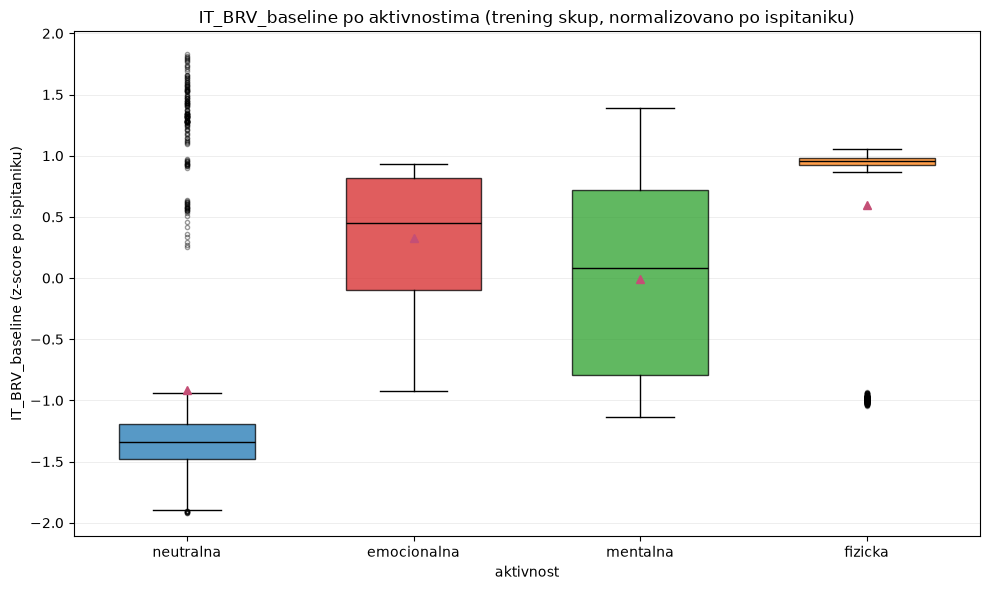

Rezime raspodele atributa IT_BRV_baseline po aktivnostima: 
             medijana  sredina     Q1     Q3    IQR
neutralna      -1.339   -0.912 -1.478 -1.196  0.281
emocionalna     0.450    0.326 -0.094  0.814  0.909
mentalna        0.083   -0.010 -0.794  0.722  1.516
fizicka         0.956    0.597  0.925  0.977  0.053
Razlika najvece i najmanje medijane po klasama:  2.2953
Prosecan IQR unutar klase:  0.6896
Odnos razlike medijana i prosecnog IQR-a:  3.3284
eta^2 (udeo varijanse koji objasnjava aktivnost):  0.3267
Preklapanje interkvartilnih raspona po parovima klasa: 
  neutralna    vs emocionalna  -> kutije se ne seku
  neutralna    vs mentalna     -> kutije se ne seku
  neutralna    vs fizicka      -> kutije se ne seku
  emocionalna  vs mentalna     -> preklapanje 0.817
  emocionalna  vs fizicka      -> kutije se ne seku
  mentalna     vs fizicka      -> kutije se ne seku


In [20]:
# Za atribut sa najvecom uzajamnom informacijom iz novog, redukovanog skupa atributa gledamo koliko dobro razdvaja aktivnosti.
# Posto je citav ovaj deo radjen nad podacima normalizovanim po ispitaniku, ovde je razdvajanje globalno - vazi kada se svi
# ispitanici posmatraju zajedno, a ne samo unutar pojedinacnog ispitanika (sto je bila zamka kod sirovih podataka).

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

top_selected_feature = mi_scores.loc[selected_features].idxmax()
top_selected_values = X_train_reduced[top_selected_feature]

print("Atribut sa najvecom uzajamnom informacijom u redukovanom skupu: ", top_selected_feature)
print("Uzajamna informacija: ", round(float(mi_scores[top_selected_feature]), 4))
print("Maksimalna moguca uzajamna informacija za 4 balansirane klase (ln 4): ", round(float(np.log(4)), 4))

fig, ax = plt.subplots(figsize=(10, 6))

boxes = ax.boxplot(
    [top_selected_values[y_train == activity] for activity in activities],
    tick_labels=[ACTIVITY_NAMES[activity] for activity in activities],
    patch_artist=True,
    showmeans=True,
    widths=0.6,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
)
for patch, activity in zip(boxes["boxes"], activities):
    patch.set_facecolor(ACTIVITY_PLOT_COLORS[activity])
    patch.set_alpha(0.75)
for median_line in boxes["medians"]:
    median_line.set_color("black")

ax.set_title(f"{top_selected_feature} po aktivnostima (trening skup, normalizovano po ispitaniku)")
ax.set_xlabel("aktivnost")
ax.set_ylabel(f"{top_selected_feature} (z-score po ispitaniku)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

# --- Brojcani rezime po klasama ---
# medijana i IQR su otporni na ekstremne vrednosti, pa se uz sredinu i kvartile najbolje vidi gde je centar klase i koliko je siroka
class_summary = pd.DataFrame({
    "medijana": top_selected_values.groupby(y_train).median(),
    "sredina": top_selected_values.groupby(y_train).mean(),
    "Q1": top_selected_values.groupby(y_train).quantile(0.25),
    "Q3": top_selected_values.groupby(y_train).quantile(0.75),
})
class_summary["IQR"] = class_summary["Q3"] - class_summary["Q1"]
class_summary.index = [ACTIVITY_NAMES[activity] for activity in class_summary.index]

print("Rezime raspodele atributa", top_selected_feature, "po aktivnostima: ")
print(class_summary.round(3).to_string())

# --- Mere koliko dobro atribut razdvaja klase ---
# 1) razlika najvece i najmanje medijane u odnosu na prosecno rasipanje unutar klase - ako je odnos mali, klase se preklapaju
median_spread = class_summary["medijana"].max() - class_summary["medijana"].min()
print("Razlika najvece i najmanje medijane po klasama: ", round(float(median_spread), 4))
print("Prosecan IQR unutar klase: ", round(float(class_summary["IQR"].mean()), 4))
print("Odnos razlike medijana i prosecnog IQR-a: ", round(float(median_spread / class_summary["IQR"].mean()), 4))

# 2) eta^2 - koliki deo ukupne varijanse atributa objasnjava bas pripadnost klasi (0 = nikakvo razdvajanje, 1 = savrseno)
print("eta^2 (udeo varijanse koji objasnjava aktivnost): ", round(float(eta_squared(top_selected_values, y_train)), 4))

# 3) koliko se parovi klasa preklapaju po interkvartilnom rasponu - ako se kutije dve klase ne seku, te dve klase atribut razdvaja sam za sebe
print("Preklapanje interkvartilnih raspona po parovima klasa: ")
for first_index, first_activity in enumerate(activities):
    for second_activity in activities[first_index + 1:]:
        first_q1, first_q3 = class_summary.loc[ACTIVITY_NAMES[first_activity], ["Q1", "Q3"]]
        second_q1, second_q3 = class_summary.loc[ACTIVITY_NAMES[second_activity], ["Q1", "Q3"]]
        overlap = min(first_q3, second_q3) - max(first_q1, second_q1)
        status = "kutije se ne seku" if overlap <= 0 else f"preklapanje {overlap:.3f}"
        print(f"  {ACTIVITY_NAMES[first_activity]:<12} vs {ACTIVITY_NAMES[second_activity]:<12} -> {status}")


Atribut sa najvecom uzajamnom informacijom (prikazan u prethodnoj celiji):  IT_BRV_baseline
Narednih sest atributa po uzajamnoj informaciji: 
  2. IT_VLF_baseline              uzajamna informacija = 0.9912
  3. ECG_amplitude_RR_min         uzajamna informacija = 0.8753
  4. IT_Original_max              uzajamna informacija = 0.8663
  5. IT_RF_max                    uzajamna informacija = 0.8541
  6. EDA_Hand_Filt2_max           uzajamna informacija = 0.8319
  7. EDA_Arm_Filt2_min            uzajamna informacija = 0.8228


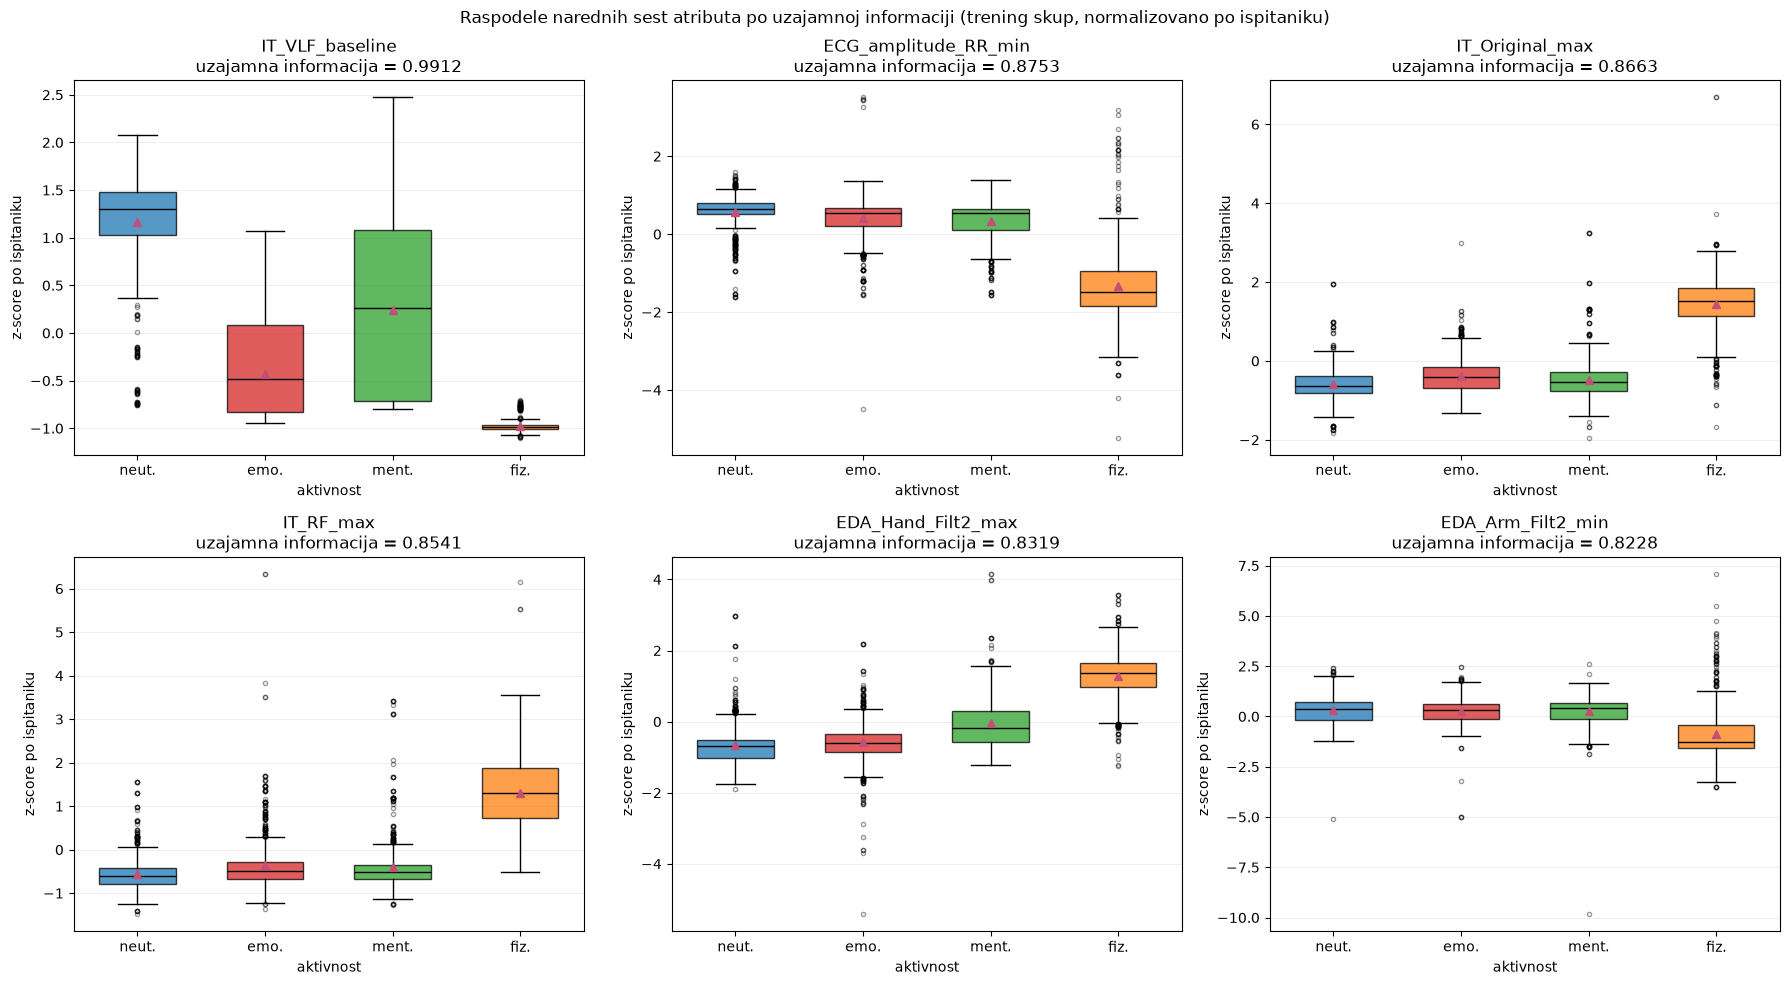


IT_VLF_baseline (uzajamna informacija 0.9912)
             medijana  sredina     Q1     Q3    IQR
neutralna       1.298    1.168  1.028  1.480  0.452
emocionalna    -0.487   -0.429 -0.831  0.081  0.912
mentalna        0.261    0.237 -0.709  1.077  1.786
fizicka        -0.986   -0.976 -1.008 -0.966  0.042
  razlika najvece i najmanje medijane:  2.2843
  prosecan IQR unutar klase:  0.7979
  odnos razlike medijana i prosecnog IQR-a:  2.863
  eta^2 (udeo varijanse koji objasnjava aktivnost):  0.6452
  parovi klasa sa razdvojenim kutijama (od 6):  4 ['neut.-emo.', 'neut.-fiz.', 'emo.-fiz.', 'ment.-fiz.']

ECG_amplitude_RR_min (uzajamna informacija 0.8753)
             medijana  sredina     Q1     Q3    IQR
neutralna       0.645    0.576  0.524  0.787  0.263
emocionalna     0.553    0.411  0.203  0.665  0.462
mentalna        0.549    0.350  0.115  0.636  0.522
fizicka        -1.488   -1.336 -1.839 -0.934  0.906
  razlika najvece i najmanje medijane:  2.1333
  prosecan IQR unutar klase:  0.5

In [21]:
# Isto poredjenje radimo i za narednih sest atributa po uzajamnoj informaciji, odmah iza vodeceg IT_BRV_baseline.
# Cilj je da se vidi da li iza prvog atributa postoji jos onih koji sami za sebe razdvajaju klase, ili uzajamna
# informacija brzo pada pa se na njih moze racunati tek u kombinaciji sa ostalima.

mi_selected_sorted = mi_scores.loc[selected_features].sort_values(ascending=False)
next_features = list(mi_selected_sorted.index[1:7])

print("Atribut sa najvecom uzajamnom informacijom (prikazan u prethodnoj celiji): ", mi_selected_sorted.index[0])
print("Narednih sest atributa po uzajamnoj informaciji: ")
for rank, feature_name in enumerate(next_features, start=2):
    print(f"  {rank}. {feature_name:<28} uzajamna informacija = {mi_selected_sorted[feature_name]:.4f}")


# Rezime raspodele jednog atributa po klasama - medijana i IQR su otporni na ekstremne vrednosti, pa se uz sredinu
# i kvartile najbolje vidi gde je centar klase i koliko je siroka.
def class_distribution_summary(values, labels):
    summary = pd.DataFrame({
        "medijana": values.groupby(labels).median(),
        "sredina": values.groupby(labels).mean(),
        "Q1": values.groupby(labels).quantile(0.25),
        "Q3": values.groupby(labels).quantile(0.75),
    })
    summary["IQR"] = summary["Q3"] - summary["Q1"]
    summary.index = [ACTIVITY_NAMES[activity] for activity in summary.index]
    return summary


# --- Boxplot-ovi po klasama za svih sest atributa, u istoj figuri ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feature_name in zip(axes.ravel(), next_features):
    feature_values = X_train_reduced[feature_name]
    boxes = ax.boxplot(
        [feature_values[y_train == activity] for activity in activities],
        tick_labels=[ACTIVITY_SHORT_NAMES[activity] for activity in activities],
        patch_artist=True,
        showmeans=True,
        widths=0.6,
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    )
    for patch, activity in zip(boxes["boxes"], activities):
        patch.set_facecolor(ACTIVITY_PLOT_COLORS[activity])
        patch.set_alpha(0.75)
    for median_line in boxes["medians"]:
        median_line.set_color("black")

    ax.set_title(f"{feature_name}\nuzajamna informacija = {mi_selected_sorted[feature_name]:.4f}")
    ax.set_xlabel("aktivnost")
    ax.set_ylabel("z-score po ispitaniku")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Raspodele narednih sest atributa po uzajamnoj informaciji (trening skup, normalizovano po ispitaniku)")
fig.tight_layout()
plt.show()

# --- Brojcani rezime po klasama, za svaki atribut posebno ---
for feature_name in next_features:
    feature_values = X_train_reduced[feature_name]
    class_summary = class_distribution_summary(feature_values, y_train)

    # razlika najvece i najmanje medijane u odnosu na prosecno rasipanje unutar klase - ako je odnos mali, klase se preklapaju
    median_spread = class_summary["medijana"].max() - class_summary["medijana"].min()
    mean_iqr = class_summary["IQR"].mean()

    # parovi klasa cije se kutije (interkvartilni rasponi) uopste ne seku - takve parove atribut razdvaja sam za sebe
    disjoint_pairs = []
    for first_index, first_activity in enumerate(activities):
        for second_activity in activities[first_index + 1:]:
            first_q1, first_q3 = class_summary.loc[ACTIVITY_NAMES[first_activity], ["Q1", "Q3"]]
            second_q1, second_q3 = class_summary.loc[ACTIVITY_NAMES[second_activity], ["Q1", "Q3"]]
            if min(first_q3, second_q3) - max(first_q1, second_q1) <= 0:
                disjoint_pairs.append(f"{ACTIVITY_SHORT_NAMES[first_activity]}-{ACTIVITY_SHORT_NAMES[second_activity]}")

    print()
    print(feature_name, " (uzajamna informacija ", round(float(mi_selected_sorted[feature_name]), 4), ")", sep="")
    print(class_summary.round(3).to_string())
    print("  razlika najvece i najmanje medijane: ", round(float(median_spread), 4))
    print("  prosecan IQR unutar klase: ", round(float(mean_iqr), 4))
    print("  odnos razlike medijana i prosecnog IQR-a: ", round(float(median_spread / mean_iqr), 4))
    print("  eta^2 (udeo varijanse koji objasnjava aktivnost): ", round(float(eta_squared(feature_values, y_train)), 4))
    print("  parovi klasa sa razdvojenim kutijama (od 6): ", len(disjoint_pairs), disjoint_pairs if disjoint_pairs else "")

# --- Uporedni pregled svih sedam atributa, ukljucujuci i vodeci iz prethodne celije ---
overview_rows = []
for feature_name in mi_selected_sorted.index[:7]:
    feature_values = X_train_reduced[feature_name]
    class_summary = class_distribution_summary(feature_values, y_train)
    median_spread = class_summary["medijana"].max() - class_summary["medijana"].min()
    disjoint_count = 0
    for first_index, first_activity in enumerate(activities):
        for second_activity in activities[first_index + 1:]:
            first_q1, first_q3 = class_summary.loc[ACTIVITY_NAMES[first_activity], ["Q1", "Q3"]]
            second_q1, second_q3 = class_summary.loc[ACTIVITY_NAMES[second_activity], ["Q1", "Q3"]]
            if min(first_q3, second_q3) - max(first_q1, second_q1) <= 0:
                disjoint_count += 1
    overview_rows.append({
        "atribut": feature_name,
        "uzajamna_informacija": mi_selected_sorted[feature_name],
        "razlika_medijana": median_spread,
        "prosecan_IQR": class_summary["IQR"].mean(),
        "odnos": median_spread / class_summary["IQR"].mean(),
        "eta^2": eta_squared(feature_values, y_train),
        "razdvojenih_parova": disjoint_count,
    })

overview = pd.DataFrame(overview_rows).set_index("atribut")
print()
print("Uporedni pregled prvih sedam atributa po uzajamnoj informaciji: ")
print(overview.round(4).to_string())


In [33]:
# mogu da negde zamenim IT_BRV_baseline sa IT_VLF_baseline, jer su jako slicni i medjusobno jesu korelisani > 0.5, ali izgledaju kao refleksija jedan drugog,
# a sa druge strane IT_VLF_baseline iako ima malo manji mutual information, ima dosta veci eta^2, i na osnovu raspodela preko boxplot-ova, razdvaja samo jedan
# par manje, pa na osnovu statistika izgleda skoro dobro kao i IT_BRV_baseline, ali pouzdanije. Naravno zbog autlajera koja su posledica podgrupe ispitanika koji
# imaju drugaciji IT_BRV_baseline, eta^2 je i naduvano manji

# IT_BRV_baseline, ECG_amplitude_RR_min
# IT_BRV_baseline, ECG_amplitude_RR_min, EDA_Hand_Filt2_max

np.float64(0.5976060092916273)